In [1]:
#!/usr/bin/env Rscript
# ================================================================
# Within-Dataset overlaps
# Trim for Tissue / Cell specific CREs
# ================================================================
suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(ggplot2)
  library(viridis)
})


Warning message:
“package ‘GenomicRanges’ was built under R version 4.3.3”
Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”
Warning message:
“package ‘S4Vectors’ was built under R version 4.3.3”
Warning message:
“package ‘IRanges’ was built under R version 4.3.3”
Warning message:
“package ‘GenomeInfoDb’ was built under R version 4.3.2”
Warning message:
“package ‘data.table’ was built under R version 4.3.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘viridis’ was built under R version 4.3.2”


### Step 1: DHS data -- Visualize the % overlap in sites between tissues

Found 16 DHS files

Processing Cancer_epithelial (78475 ranges)
  Cancer_epithelial vs Cancer_epithelial → 100.00% overlap
  Cancer_epithelial vs Cardiac → 0.92% overlap
  Cancer_epithelial vs Digestive → 1.44% overlap
  Cancer_epithelial vs Lymphoid → 0.94% overlap
  Cancer_epithelial vs Musculoskeletal → 0.98% overlap
  Cancer_epithelial vs Myeloid_erythroid → 0.90% overlap
  Cancer_epithelial vs Neural → 0.85% overlap
  Cancer_epithelial vs Organ_devel_renal → 0.94% overlap
  Cancer_epithelial vs Placental_trophoblast → 1.18% overlap
  Cancer_epithelial vs Primitive_embryonic → 0.80% overlap
  Cancer_epithelial vs Pulmonary_devel → 0.90% overlap
  Cancer_epithelial vs Renal_cancer → 1.43% overlap
  Cancer_epithelial vs Stromal_A → 1.64% overlap
  Cancer_epithelial vs Stromal_B → 1.30% overlap
  Cancer_epithelial vs Tissue_invariant → 0.96% overlap
  Cancer_epithelial vs Vascular_endothelial → 1.16% overlap

Processing Cardiac (61601 ranges)
  Cardiac vs Cancer_epithelial → 0.70% ove

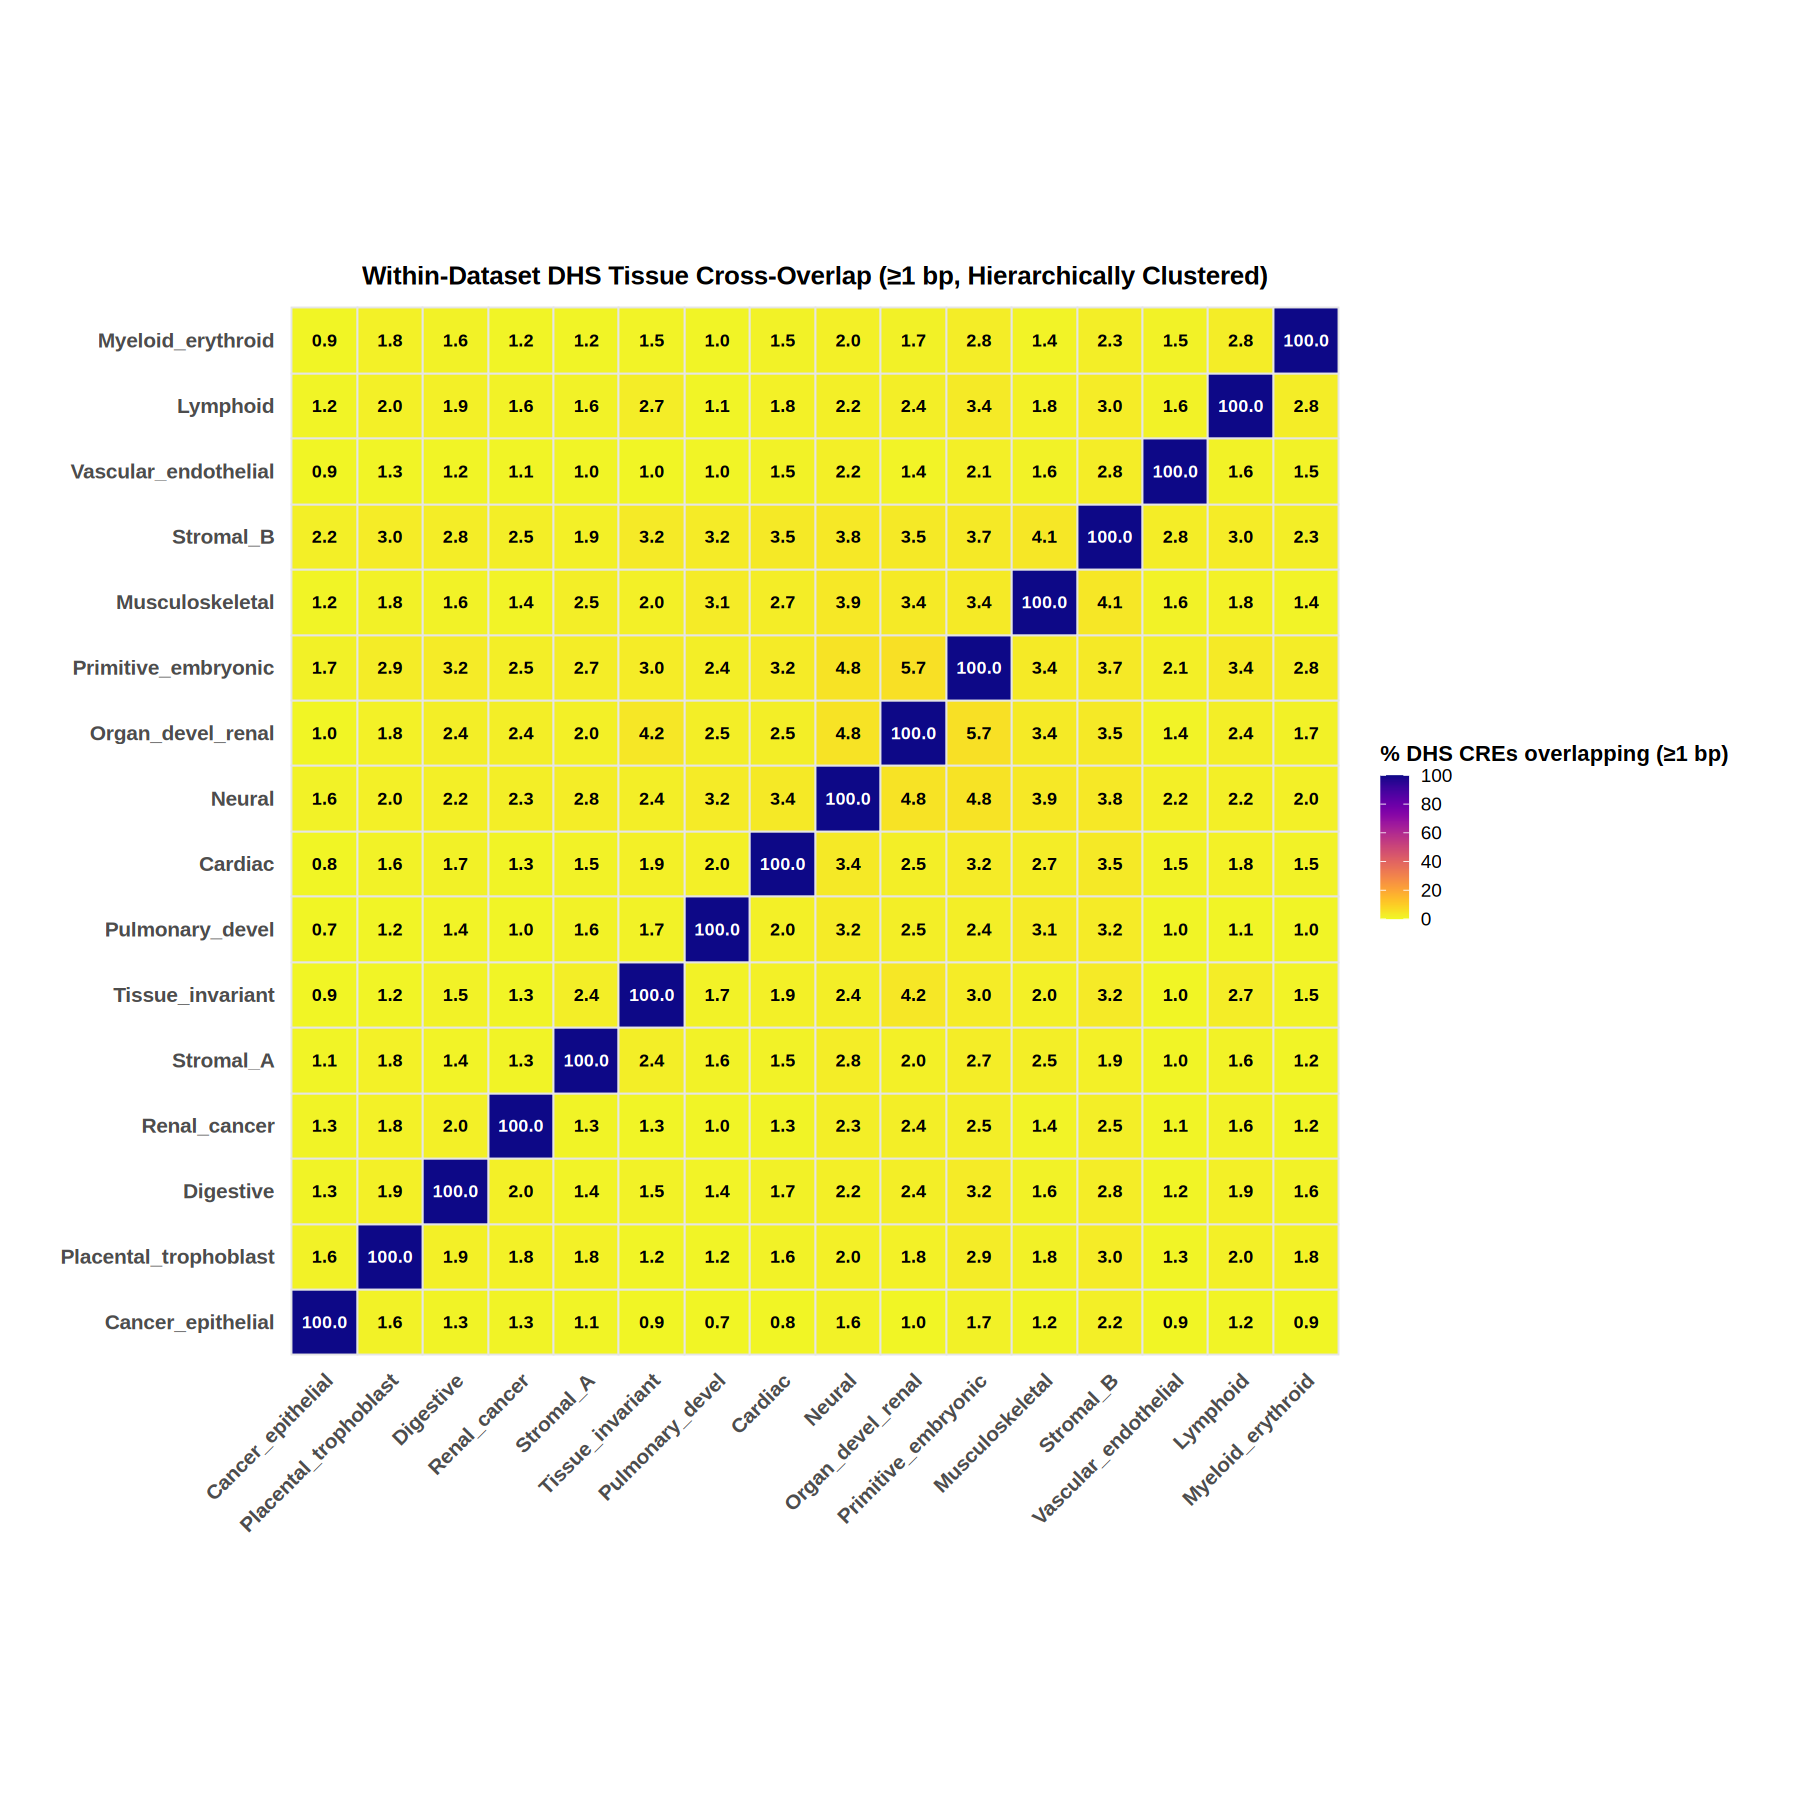

In [2]:
#!/usr/bin/env Rscript
# ===================================================================
# cfDNA CRE Reference – DHS Within-Dataset Cross-Tissue Overlap
# ===================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(ggplot2)
  library(viridis)
})

# ------------------------------------------------
# Paths
# ------------------------------------------------
dhs_dir <- "../ref/CRE_sites_QC/DHS_sites_QC2"
out_png <- "../ref/CRE_sites_Selective/DHS_within_cross_tissue_overlaps.png"

# ------------------------------------------------
# Files
# ------------------------------------------------
dhs_files <- list.files(dhs_dir, pattern="\\.rds$", full.names=TRUE)
cat(sprintf("Found %d DHS files\n", length(dhs_files)))

get_name <- function(path) gsub("_filtered(\\.hg19)?\\.rds$", "", basename(path))

# ------------------------------------------------
# Overlap function (≥ 1 bp)
# ------------------------------------------------
compute_overlap_pct <- function(gr1, gr2) {
  hits <- findOverlaps(gr1, gr2, ignore.strand=TRUE)
  if (length(hits) == 0) return(0)
  pct <- 100 * length(unique(subjectHits(hits))) / length(gr2)
  return(pct)
}

# ------------------------------------------------
# Compute all pairwise overlaps
# ------------------------------------------------
overlap_dt <- data.table()
for (i in seq_along(dhs_files)) {
  gr_i <- readRDS(dhs_files[i])
  name_i <- get_name(dhs_files[i])
  cat(sprintf("\nProcessing %s (%d ranges)\n", name_i, length(gr_i)))
  for (j in seq_along(dhs_files)) {
    gr_j <- readRDS(dhs_files[j])
    name_j <- get_name(dhs_files[j])
    pct <- compute_overlap_pct(gr_i, gr_j)
    overlap_dt <- rbind(overlap_dt,
                        data.table(Tissue1 = name_i,
                                   Tissue2 = name_j,
                                   pct_overlap = pct))
    cat(sprintf("  %s vs %s → %.2f%% overlap\n", name_i, name_j, pct))
  }
}

# ------------------------------------------------
# Create symmetric matrix
# ------------------------------------------------
mat <- dcast(overlap_dt, Tissue1 ~ Tissue2, value.var="pct_overlap", fill=0)
row_names <- mat$Tissue1
mat_num <- as.matrix(mat[, -1, with=FALSE])
rownames(mat_num) <- row_names

# Make symmetric by averaging i→j and j→i
mat_sym <- (mat_num + t(mat_num)) / 2

# ------------------------------------------------
# Hierarchical clustering for ordering
# ------------------------------------------------
order <- hclust(dist(mat_sym))$order
tissues_ordered <- rownames(mat_sym)[order]
overlap_melt <- as.data.table(as.table(mat_sym))
setnames(overlap_melt, c("Tissue1","Tissue2","pct_overlap"))
overlap_melt$Tissue1 <- factor(overlap_melt$Tissue1, levels=tissues_ordered)
overlap_melt$Tissue2 <- factor(overlap_melt$Tissue2, levels=tissues_ordered)

# ------------------------------------------------
# BEAUTIFUL HEATMAP
# ------------------------------------------------
tile_text_size <- 6 * (10 / length(tissues_ordered))
overlap_melt$text_color <- ifelse(overlap_melt$pct_overlap > 50, "white", "black")

gf <- ggplot(overlap_melt, aes(x=Tissue2, y=Tissue1, fill=pct_overlap)) +
  geom_tile(color="grey90", linewidth=0.4) +
  geom_text(aes(label=sprintf("%.1f", pct_overlap), color=text_color),
            size=tile_text_size, fontface="bold") +
  scale_color_identity() +
  scale_fill_viridis(
    name="% DHS CREs overlapping (≥1 bp)",
    option="C", direction=-1,
    limits=c(0,100),
    breaks=seq(0,100,by=20)
  ) +
  coord_fixed() +
  theme_minimal(base_size=14) +
  theme(
    aspect.ratio=1,
    axis.text.x=element_text(angle=45,hjust=1,vjust=1,size=12,face="bold"),
    axis.text.y=element_text(size=12,face="bold"),
    axis.title=element_blank(),
    panel.grid=element_blank(),
    legend.position="right",
    legend.title=element_text(face="bold",size=13),
    legend.text=element_text(size=11),
    plot.title=element_text(face="bold",size=15,hjust=0.5),
    plot.margin=margin(20,40,20,40)
  ) +
  ggtitle("Within-Dataset DHS Tissue Cross-Overlap (≥1 bp, Hierarchically Clustered)")

options(repr.plot.width=15, repr.plot.height=15)
print(gf)

# ------------------------------------------------
# Save figure
# ------------------------------------------------
#ggsave(filename=out_png, plot=gf, width=15, height=15, dpi=300)
cat(sprintf("\n✅ Heatmap saved to: %s\n", out_png))


Found 16 DHS files

Processing Cancer_epithelial (78475 summits)
  Cancer_epithelial vs Cancer_epithelial → 100.00% overlap
  Cancer_epithelial vs Cardiac → 2.12% overlap
  Cancer_epithelial vs Digestive → 3.05% overlap
  Cancer_epithelial vs Lymphoid → 2.13% overlap
  Cancer_epithelial vs Musculoskeletal → 2.15% overlap
  Cancer_epithelial vs Myeloid_erythroid → 2.17% overlap
  Cancer_epithelial vs Neural → 1.85% overlap
  Cancer_epithelial vs Organ_devel_renal → 2.10% overlap
  Cancer_epithelial vs Placental_trophoblast → 2.72% overlap
  Cancer_epithelial vs Primitive_embryonic → 1.82% overlap
  Cancer_epithelial vs Pulmonary_devel → 2.21% overlap
  Cancer_epithelial vs Renal_cancer → 3.39% overlap
  Cancer_epithelial vs Stromal_A → 4.80% overlap
  Cancer_epithelial vs Stromal_B → 3.04% overlap
  Cancer_epithelial vs Tissue_invariant → 2.57% overlap
  Cancer_epithelial vs Vascular_endothelial → 2.61% overlap

Processing Cardiac (61601 summits)
  Cardiac vs Cancer_epithelial → 1.60% o

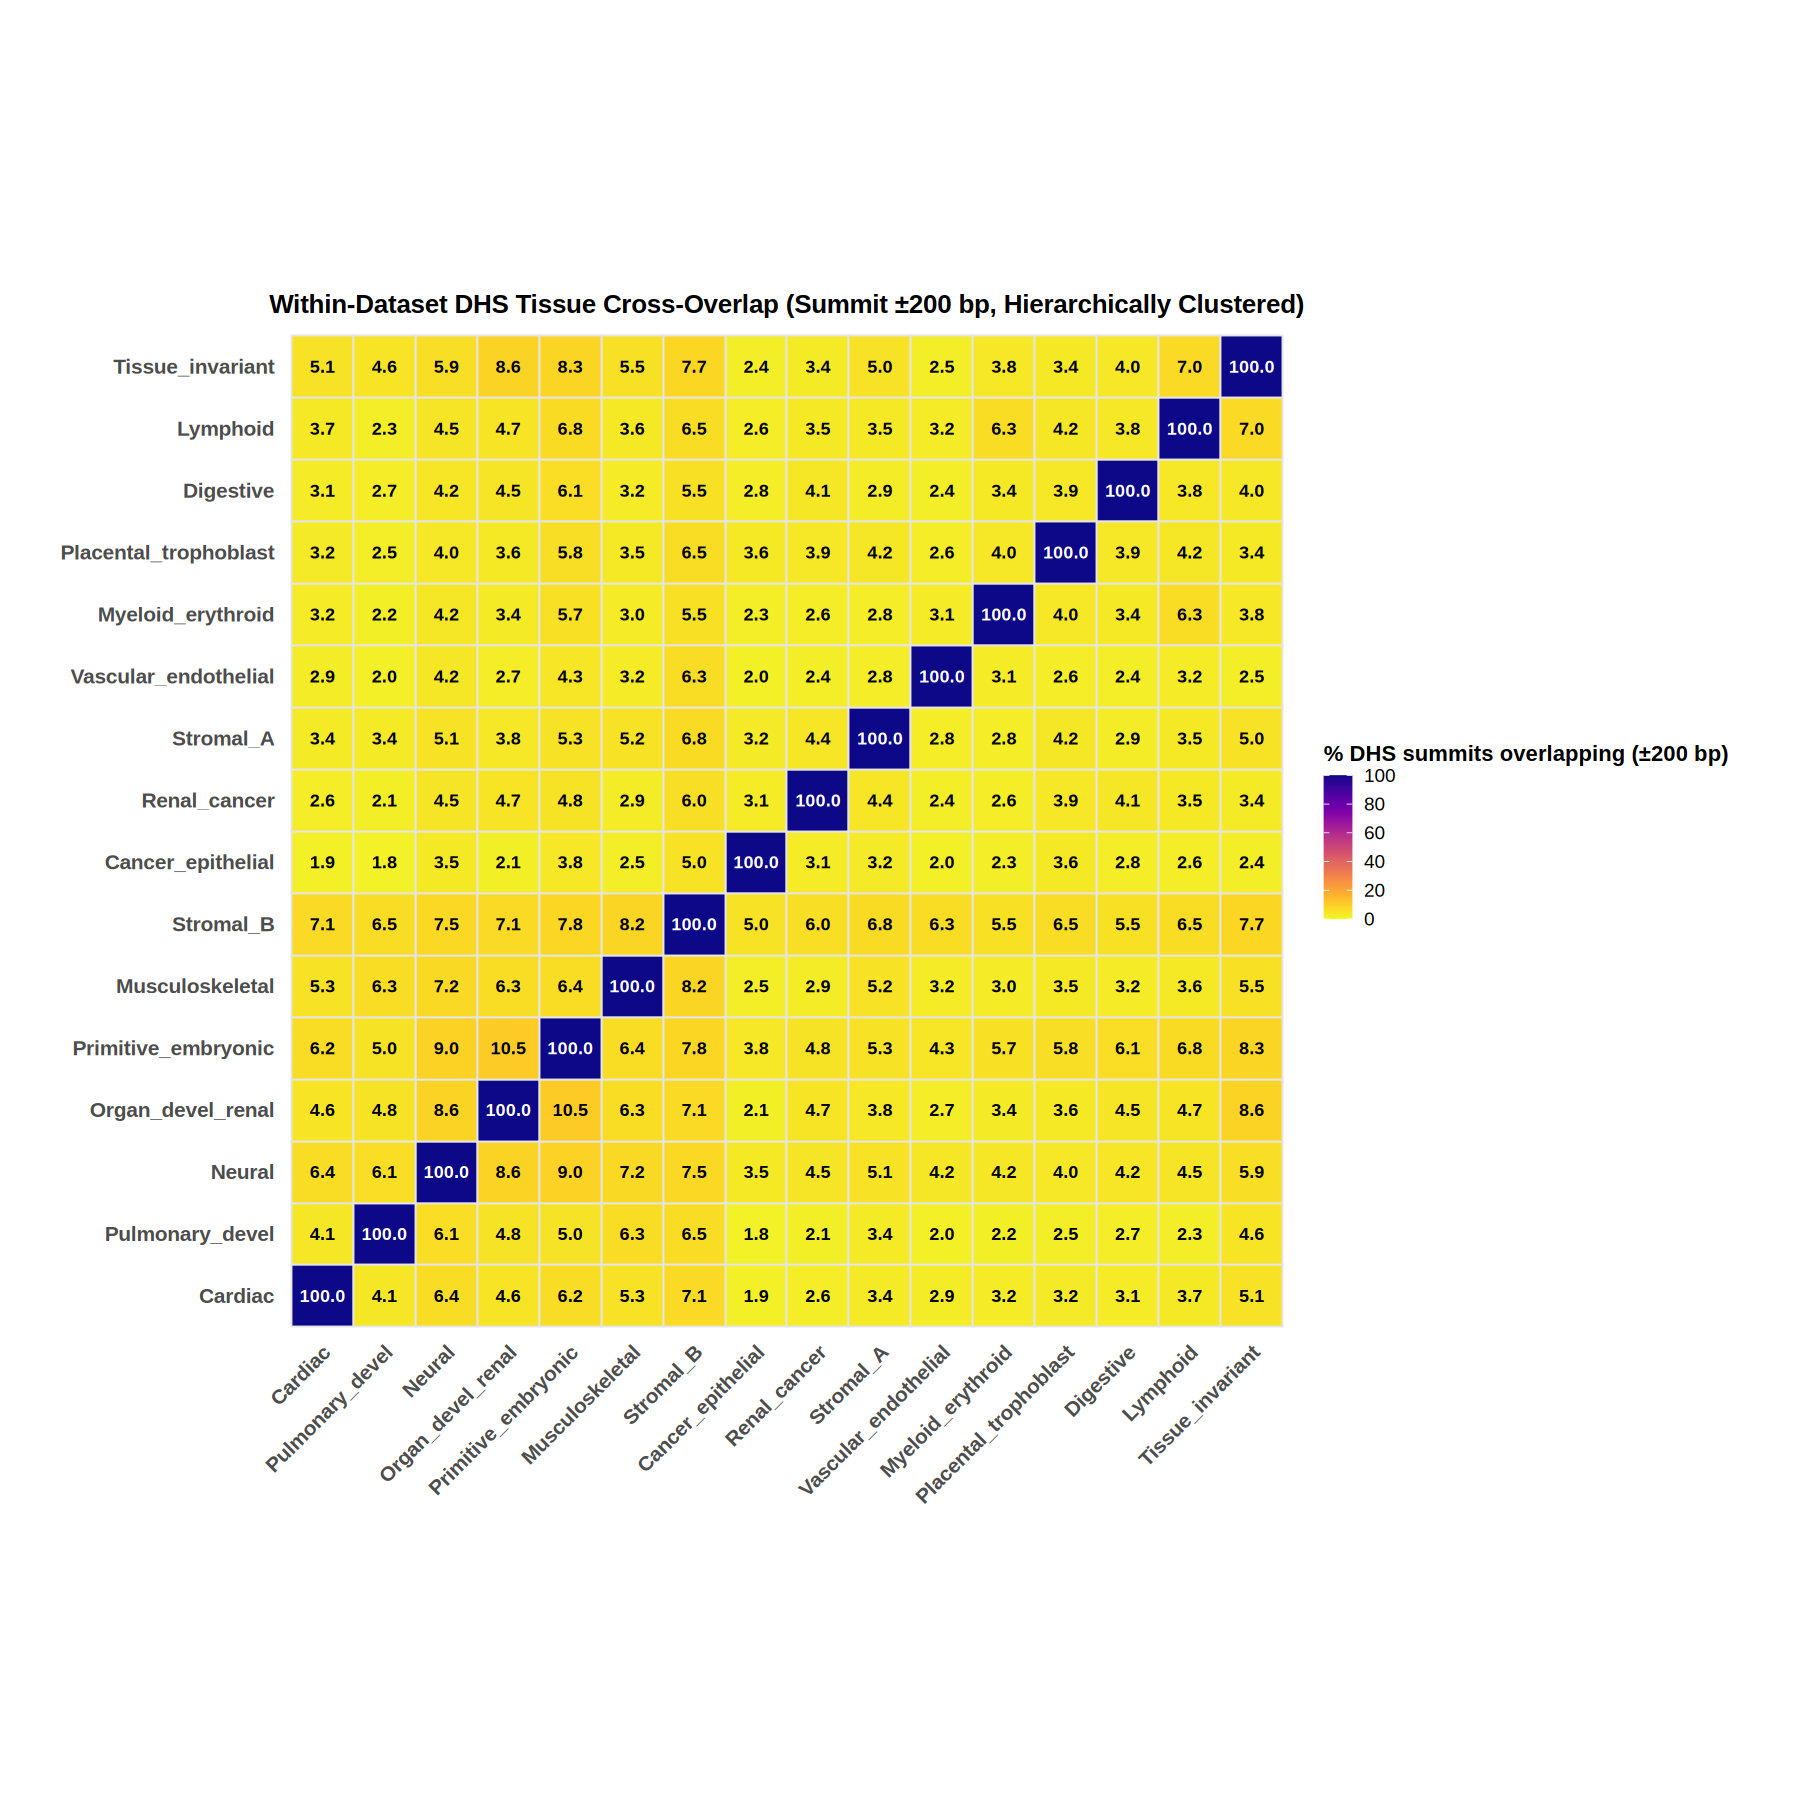

In [4]:
#!/usr/bin/env Rscript
# ===================================================================
# cfDNA CRE Reference – DHS Within-Dataset Cross-Tissue Overlap (Summit ±200 bp)
# ===================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(ggplot2)
  library(viridis)
})

# ------------------------------------------------
# Paths
# ------------------------------------------------
dhs_dir <- "../ref/CRE_sites_QC/DHS_sites_QC2"
out_png <- "../ref/CRE_sites_Selective/DHS_within_cross_tissue_overlaps_summit200bp.png"

# ------------------------------------------------
# Files
# ------------------------------------------------
dhs_files <- list.files(dhs_dir, pattern="\\.rds$", full.names=TRUE)
cat(sprintf("Found %d DHS files\n", length(dhs_files)))

get_name <- function(path) gsub("_filtered(\\.hg19)?\\.rds$", "", basename(path))

# ------------------------------------------------
# Utility: convert "summit_hg19" column → GRanges ±200 bp window
# ------------------------------------------------
make_summit_gr <- function(gr, flank=200) {
  if (!"summit_hg19" %in% names(mcols(gr))) {
    stop("Missing 'summit_hg19' column in metadata.")
  }
  starts <- pmax(1, gr$summit_hg19 - flank)
  ends   <- gr$summit_hg19 + flank
  GRanges(seqnames=seqnames(gr), ranges=IRanges(start=starts, end=ends))
}

# ------------------------------------------------
# Overlap function (≥ 1 bp)
# ------------------------------------------------
compute_overlap_pct <- function(gr1, gr2) {
  hits <- findOverlaps(gr1, gr2, ignore.strand=TRUE)
  if (length(hits) == 0) return(0)
  pct <- 100 * length(unique(subjectHits(hits))) / length(gr2)
  return(pct)
}

# ------------------------------------------------
# Compute all pairwise overlaps
# ------------------------------------------------
overlap_dt <- data.table()
for (i in seq_along(dhs_files)) {
  gr_i_full <- readRDS(dhs_files[i])
  name_i <- get_name(dhs_files[i])
  gr_i <- make_summit_gr(gr_i_full, flank=200)
  cat(sprintf("\nProcessing %s (%d summits)\n", name_i, length(gr_i)))

  for (j in seq_along(dhs_files)) {
    gr_j_full <- readRDS(dhs_files[j])
    name_j <- get_name(dhs_files[j])
    gr_j <- make_summit_gr(gr_j_full, flank=200)

    pct <- compute_overlap_pct(gr_i, gr_j)
    overlap_dt <- rbind(overlap_dt,
                        data.table(Tissue1=name_i,
                                   Tissue2=name_j,
                                   pct_overlap=pct))
    cat(sprintf("  %s vs %s → %.2f%% overlap\n", name_i, name_j, pct))
  }
}

# ------------------------------------------------
# Build symmetric matrix
# ------------------------------------------------
mat <- dcast(overlap_dt, Tissue1 ~ Tissue2, value.var="pct_overlap", fill=0)
row_names <- mat$Tissue1
mat_num <- as.matrix(mat[, -1, with=FALSE])
rownames(mat_num) <- row_names
mat_sym <- (mat_num + t(mat_num)) / 2

# ------------------------------------------------
# Hierarchical clustering
# ------------------------------------------------
order <- hclust(dist(mat_sym))$order
tissues_ordered <- rownames(mat_sym)[order]
overlap_melt <- as.data.table(as.table(mat_sym))
setnames(overlap_melt, c("Tissue1","Tissue2","pct_overlap"))
overlap_melt$Tissue1 <- factor(overlap_melt$Tissue1, levels=tissues_ordered)
overlap_melt$Tissue2 <- factor(overlap_melt$Tissue2, levels=tissues_ordered)

# ------------------------------------------------
# BEAUTIFUL HEATMAP
# ------------------------------------------------
tile_text_size <- 6 * (10 / length(tissues_ordered))
overlap_melt$text_color <- ifelse(overlap_melt$pct_overlap > 50, "white", "black")

gf <- ggplot(overlap_melt, aes(x=Tissue2, y=Tissue1, fill=pct_overlap)) +
  geom_tile(color="grey90", linewidth=0.4) +
  geom_text(aes(label=sprintf("%.1f", pct_overlap), color=text_color),
            size=tile_text_size, fontface="bold") +
  scale_color_identity() +
  scale_fill_viridis(
    name="% DHS summits overlapping (±200 bp)",
    option="C", direction=-1,
    limits=c(0,100), breaks=seq(0,100,by=20)
  ) +
  coord_fixed() +
  theme_minimal(base_size=14) +
  theme(
    aspect.ratio=1,
    axis.text.x=element_text(angle=45,hjust=1,vjust=1,size=12,face="bold"),
    axis.text.y=element_text(size=12,face="bold"),
    axis.title=element_blank(),
    panel.grid=element_blank(),
    legend.position="right",
    legend.title=element_text(face="bold",size=13),
    legend.text=element_text(size=11),
    plot.title=element_text(face="bold",size=15,hjust=0.5),
    plot.margin=margin(20,40,20,40)
  ) +
  ggtitle("Within-Dataset DHS Tissue Cross-Overlap (Summit ±200 bp, Hierarchically Clustered)")

options(repr.plot.width=15, repr.plot.height=15)
print(gf)

# ------------------------------------------------
# Save
# ------------------------------------------------
ggsave(filename=out_png, plot=gf, width=15, height=15, dpi=300)
cat(sprintf("\n✅ Heatmap saved to: %s\n", out_png))


### Step 2: scATAC data -- Visualize the % overlap in sites between cell types

Found 20 scATAC files

Processing Adrenal_Cortical (21000 ranges)
  Adrenal_Cortical vs Adrenal_Cortical → 100.00% overlap
  Adrenal_Cortical vs Adult_Stromal → 0.01% overlap
  Adrenal_Cortical vs Cardiomyocyte → 0.00% overlap
  Adrenal_Cortical vs Endothelial → 0.01% overlap
  Adrenal_Cortical vs Erythroid → 0.02% overlap
  Adrenal_Cortical vs Fetal_Neuronal_Glial → 0.00% overlap
  Adrenal_Cortical vs Follicular → 0.00% overlap
  Adrenal_Cortical vs Gastric_Epithelial → 0.00% overlap
  Adrenal_Cortical vs GI_Epithelial → 0.01% overlap
  Adrenal_Cortical vs Hepatocyte → 0.00% overlap
  Adrenal_Cortical vs Immune → 0.00% overlap
  Adrenal_Cortical vs Neuroendocrine → 0.00% overlap
  Adrenal_Cortical vs Neuronal_Glial → 0.00% overlap
  Adrenal_Cortical vs Pancreatic_Epithelial → 0.00% overlap
  Adrenal_Cortical vs Placental → 0.00% overlap
  Adrenal_Cortical vs Pulm_Epithelial → 0.00% overlap
  Adrenal_Cortical vs Skeletal_Myocyte → 0.01% overlap
  Adrenal_Cortical vs Skin_Mammary_Epithe

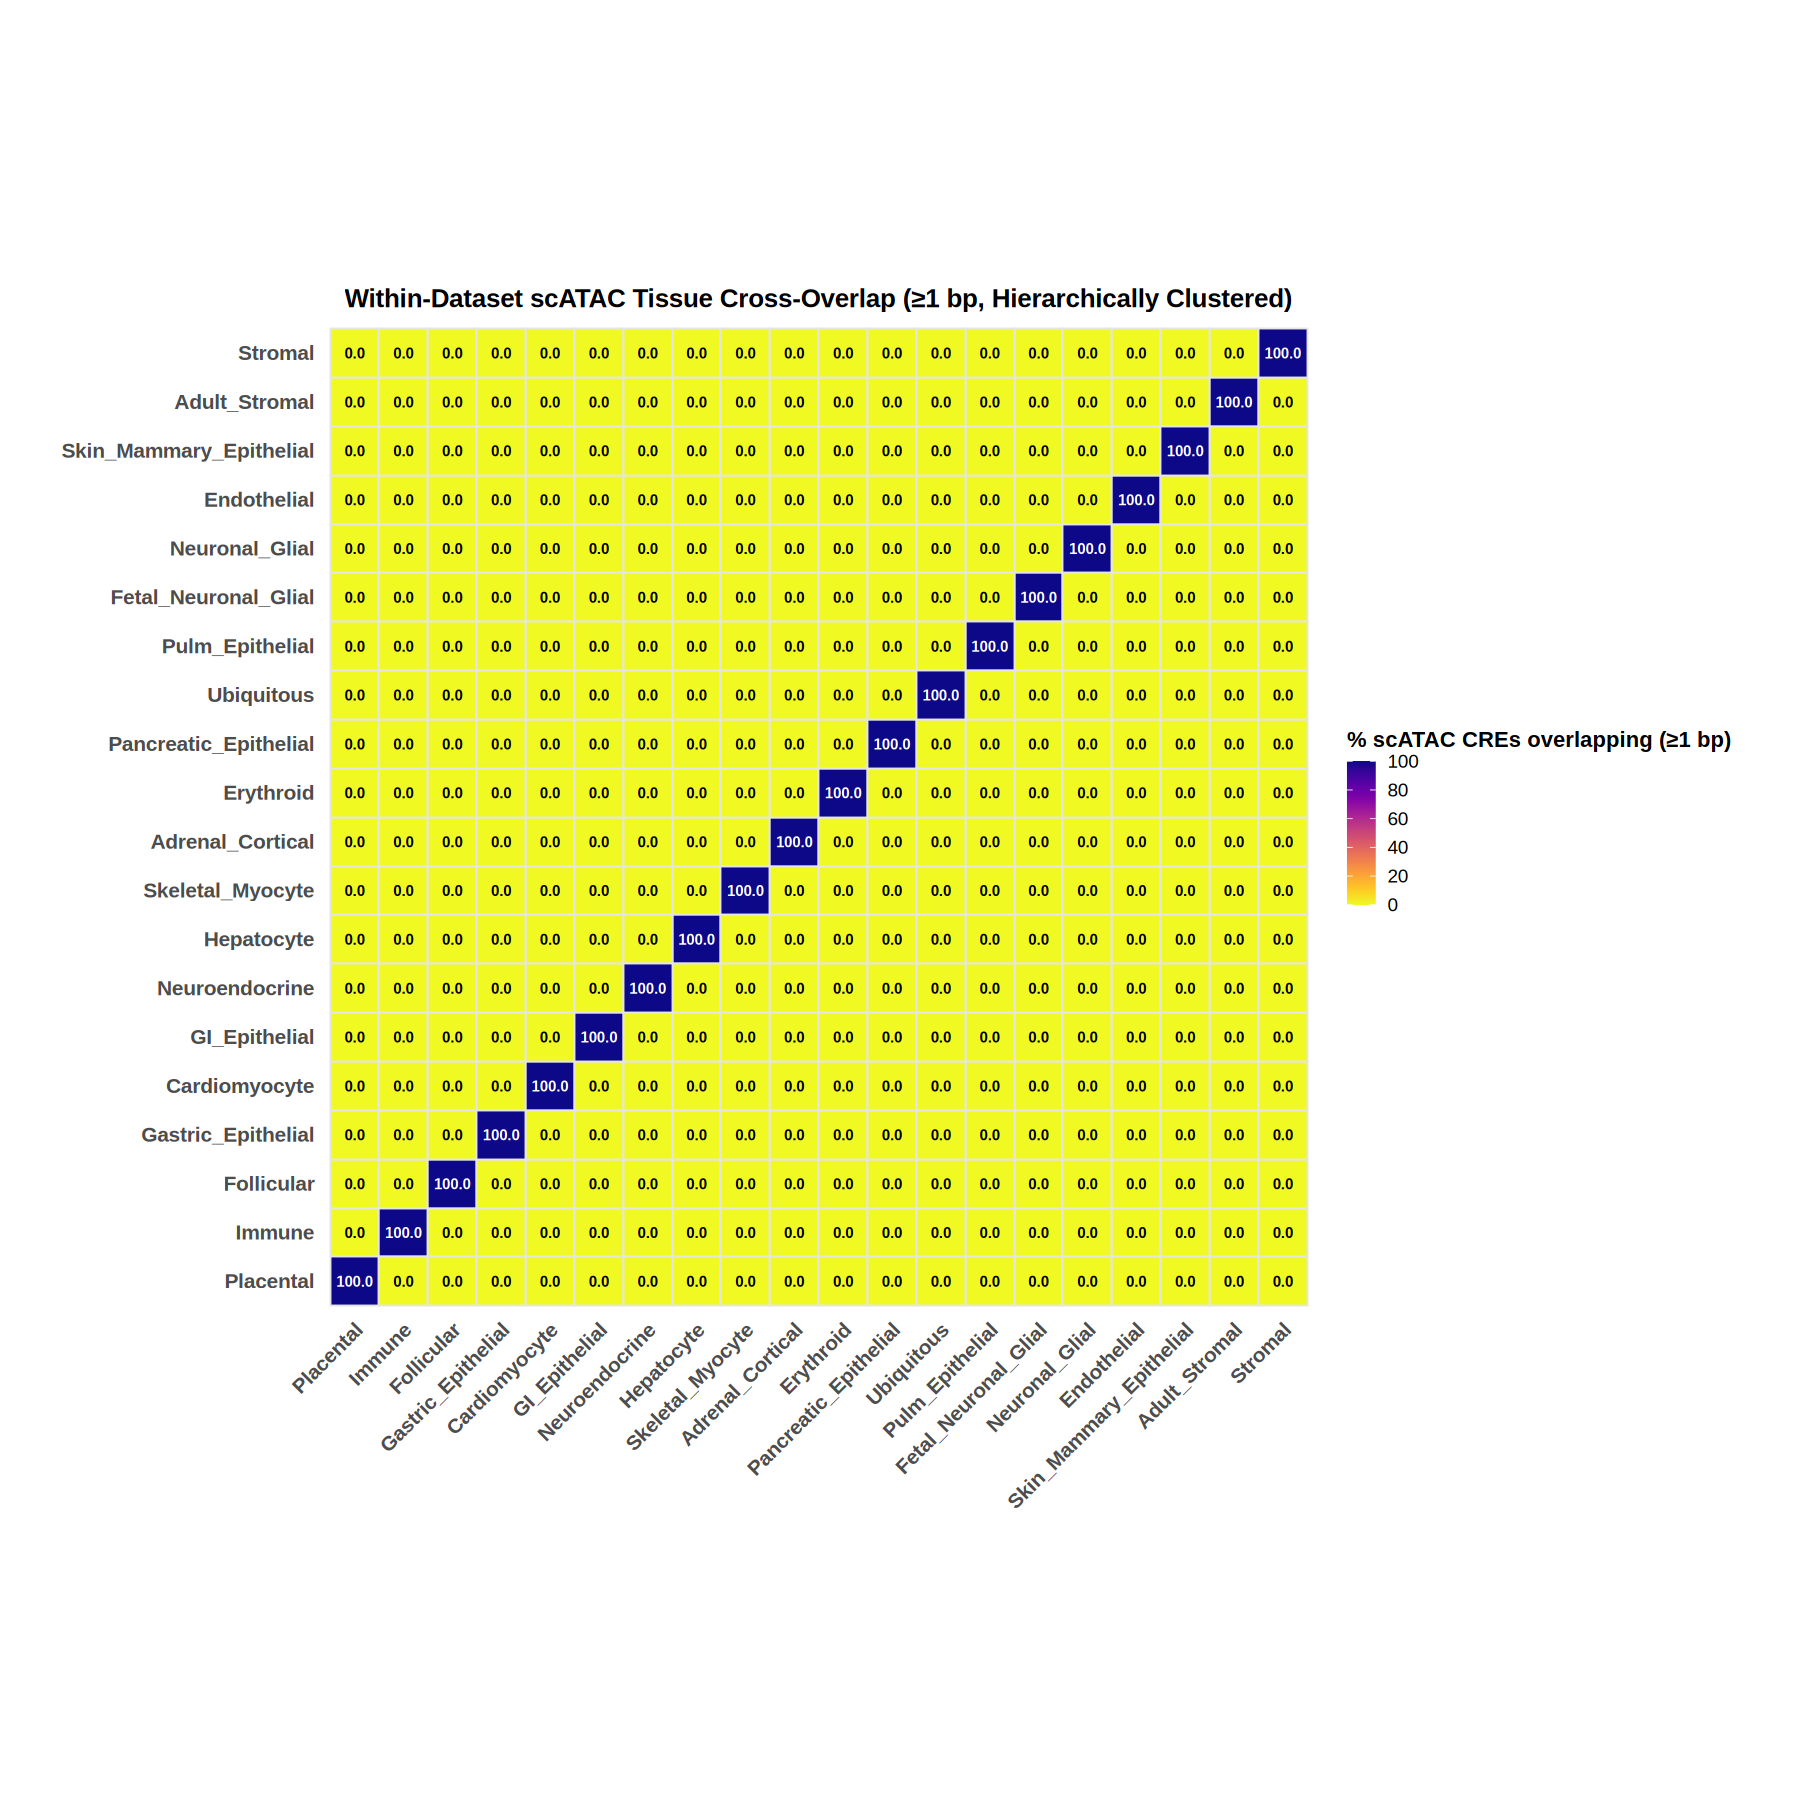

In [5]:
#!/usr/bin/env Rscript
# ===================================================================
# cfDNA CRE Reference – scATAC Within-Dataset Cross-Tissue Overlap
# ===================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(ggplot2)
  library(viridis)
})

# ------------------------------------------------
# Paths
# ------------------------------------------------
atac_dir <- "../ref/CRE_sites_QC/scATAC_sites_QC2"
out_png  <- "../ref/CRE_sites_Selective/scATAC_within_cross_tissue_overlaps.png"

# ------------------------------------------------
# Files
# ------------------------------------------------
atac_files <- list.files(atac_dir, pattern="\\.rds$", full.names=TRUE)
cat(sprintf("Found %d scATAC files\n", length(atac_files)))

get_name <- function(path) gsub("_filtered(\\.hg19)?\\.rds$", "", basename(path))

# ------------------------------------------------
# Overlap function (≥ 1 bp)
# ------------------------------------------------
compute_overlap_pct <- function(gr1, gr2) {
  hits <- findOverlaps(gr1, gr2, ignore.strand=TRUE)
  if (length(hits) == 0) return(0)
  pct <- 100 * length(unique(subjectHits(hits))) / length(gr2)
  return(pct)
}

# ------------------------------------------------
# Compute all pairwise overlaps
# ------------------------------------------------
overlap_dt <- data.table()
for (i in seq_along(atac_files)) {
  gr_i <- readRDS(atac_files[i])
  name_i <- get_name(atac_files[i])
  cat(sprintf("\nProcessing %s (%d ranges)\n", name_i, length(gr_i)))

  for (j in seq_along(atac_files)) {
    gr_j <- readRDS(atac_files[j])
    name_j <- get_name(atac_files[j])

    pct <- compute_overlap_pct(gr_i, gr_j)
    overlap_dt <- rbind(
      overlap_dt,
      data.table(Tissue1 = name_i,
                 Tissue2 = name_j,
                 pct_overlap = pct)
    )
    cat(sprintf("  %s vs %s → %.2f%% overlap\n", name_i, name_j, pct))
  }
}

# ------------------------------------------------
# Create symmetric matrix
# ------------------------------------------------
mat <- dcast(overlap_dt, Tissue1 ~ Tissue2, value.var="pct_overlap", fill=0)
row_names <- mat$Tissue1
mat_num <- as.matrix(mat[, -1, with=FALSE])
rownames(mat_num) <- row_names

# Make symmetric by averaging i→j and j→i
mat_sym <- (mat_num + t(mat_num)) / 2

# ------------------------------------------------
# Hierarchical clustering for ordering
# ------------------------------------------------
order <- hclust(dist(mat_sym))$order
tissues_ordered <- rownames(mat_sym)[order]
overlap_melt <- as.data.table(as.table(mat_sym))
setnames(overlap_melt, c("Tissue1","Tissue2","pct_overlap"))
overlap_melt$Tissue1 <- factor(overlap_melt$Tissue1, levels=tissues_ordered)
overlap_melt$Tissue2 <- factor(overlap_melt$Tissue2, levels=tissues_ordered)

# ------------------------------------------------
# BEAUTIFUL HEATMAP
# ------------------------------------------------
tile_text_size <- 6 * (10 / length(tissues_ordered))
overlap_melt$text_color <- ifelse(overlap_melt$pct_overlap > 50, "white", "black")

gf <- ggplot(overlap_melt, aes(x=Tissue2, y=Tissue1, fill=pct_overlap)) +
  geom_tile(color="grey90", linewidth=0.4) +
  geom_text(aes(label=sprintf("%.1f", pct_overlap), color=text_color),
            size=tile_text_size, fontface="bold") +
  scale_color_identity() +
  scale_fill_viridis(
    name="% scATAC CREs overlapping (≥1 bp)",
    option="C", direction=-1,
    limits=c(0,100),
    breaks=seq(0,100,by=20)
  ) +
  coord_fixed() +
  theme_minimal(base_size=14) +
  theme(
    aspect.ratio=1,
    axis.text.x=element_text(angle=45,hjust=1,vjust=1,size=12,face="bold"),
    axis.text.y=element_text(size=12,face="bold"),
    axis.title=element_blank(),
    panel.grid=element_blank(),
    legend.position="right",
    legend.title=element_text(face="bold",size=13),
    legend.text=element_text(size=11),
    plot.title=element_text(face="bold",size=15,hjust=0.5),
    plot.margin=margin(20,40,20,40)
  ) +
  ggtitle("Within-Dataset scATAC Tissue Cross-Overlap (≥1 bp, Hierarchically Clustered)")

options(repr.plot.width=15, repr.plot.height=15)
print(gf)

# ------------------------------------------------
# Save figure
# ------------------------------------------------
ggsave(filename=out_png, plot=gf, width=15, height=15, dpi=300)
cat(sprintf("\n✅ Heatmap saved to: %s\n", out_png))


Found 20 scATAC files

Processing Adrenal_Cortical (21000 summits)
  Adrenal_Cortical vs Adrenal_Cortical → 100.00% overlap
  Adrenal_Cortical vs Adult_Stromal → 0.01% overlap
  Adrenal_Cortical vs Cardiomyocyte → 0.00% overlap
  Adrenal_Cortical vs Endothelial → 0.01% overlap
  Adrenal_Cortical vs Erythroid → 0.02% overlap
  Adrenal_Cortical vs Fetal_Neuronal_Glial → 0.00% overlap
  Adrenal_Cortical vs Follicular → 0.00% overlap
  Adrenal_Cortical vs Gastric_Epithelial → 0.00% overlap
  Adrenal_Cortical vs GI_Epithelial → 0.01% overlap
  Adrenal_Cortical vs Hepatocyte → 0.00% overlap
  Adrenal_Cortical vs Immune → 0.00% overlap
  Adrenal_Cortical vs Neuroendocrine → 0.00% overlap
  Adrenal_Cortical vs Neuronal_Glial → 0.00% overlap
  Adrenal_Cortical vs Pancreatic_Epithelial → 0.00% overlap
  Adrenal_Cortical vs Placental → 0.00% overlap
  Adrenal_Cortical vs Pulm_Epithelial → 0.00% overlap
  Adrenal_Cortical vs Skeletal_Myocyte → 0.01% overlap
  Adrenal_Cortical vs Skin_Mammary_Epith

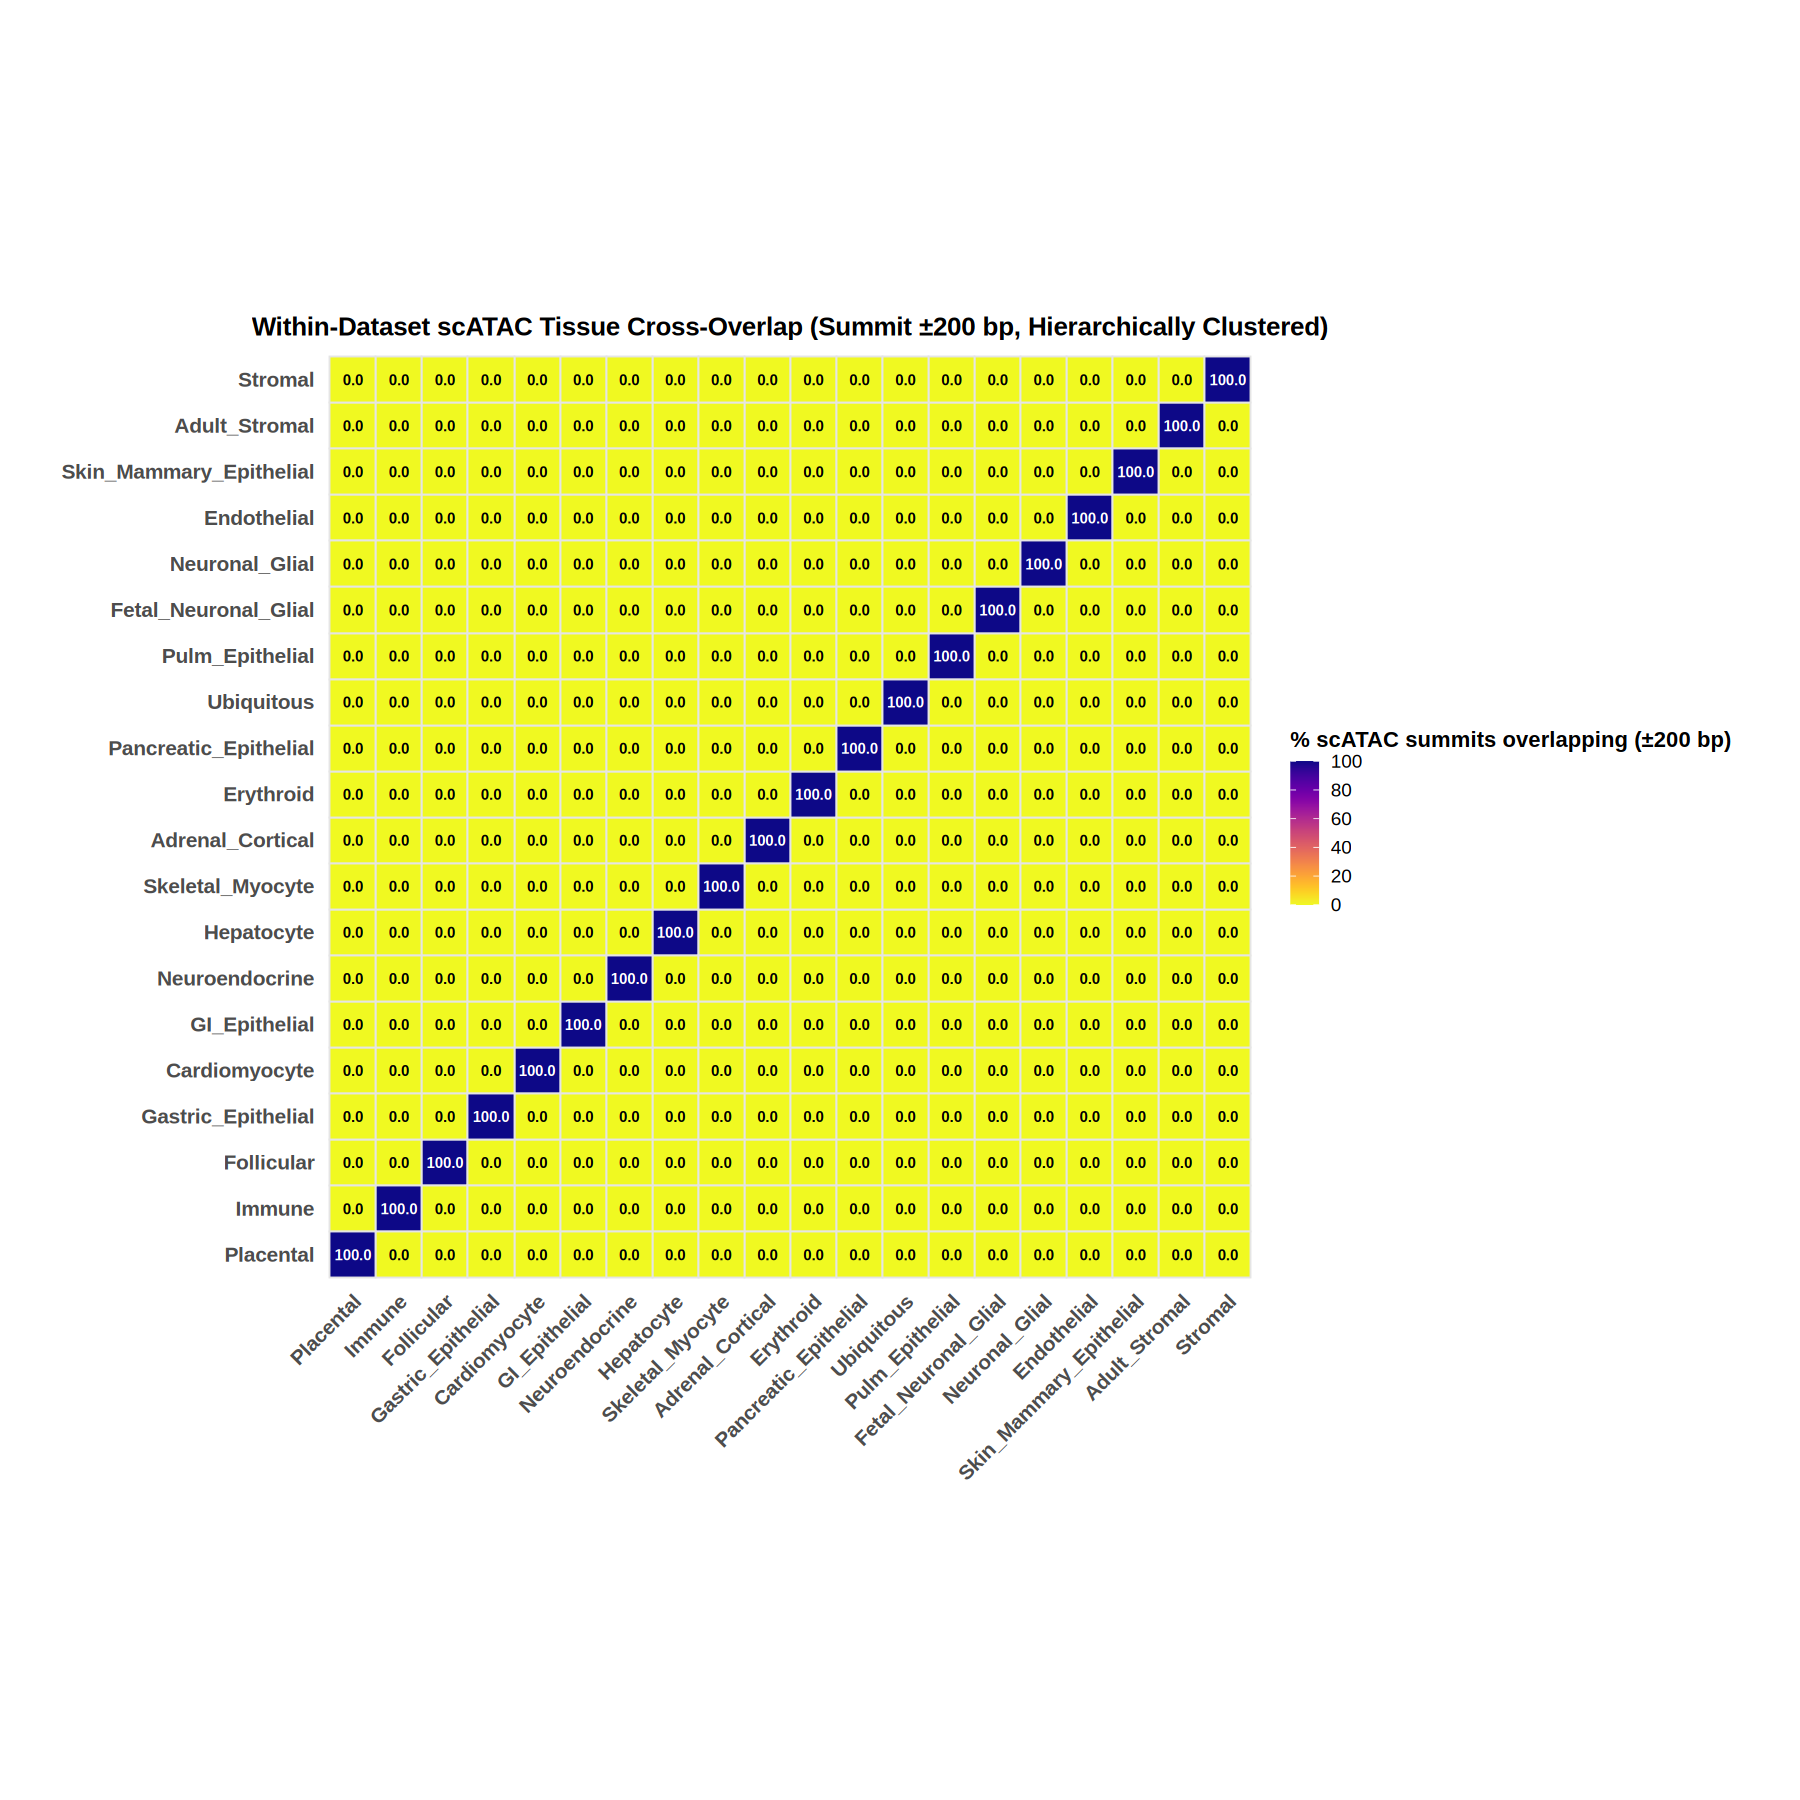

In [6]:
#!/usr/bin/env Rscript
# ===================================================================
# cfDNA CRE Reference – scATAC Within-Dataset Cross-Tissue Overlap (Summit ±200 bp)
# ===================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(ggplot2)
  library(viridis)
})

# ------------------------------------------------
# Paths
# ------------------------------------------------
atac_dir <- "../ref/CRE_sites_QC/scATAC_sites_QC2"
out_png  <- "../ref/CRE_sites_Selective/scATAC_within_cross_tissue_overlaps_summit200bp.png"

# ------------------------------------------------
# Files
# ------------------------------------------------
atac_files <- list.files(atac_dir, pattern="\\.rds$", full.names=TRUE)
cat(sprintf("Found %d scATAC files\n", length(atac_files)))

get_name <- function(path) gsub("_filtered(\\.hg19)?\\.rds$", "", basename(path))

# ------------------------------------------------
# Utility: convert ATAC_summit_hg19 → GRanges ±200 bp
# ------------------------------------------------
make_summit_gr <- function(gr, flank=200) {
  if (!"ATAC_summit_hg19" %in% names(mcols(gr))) {
    stop("Missing 'ATAC_summit_hg19' column in metadata.")
  }
  starts <- pmax(1, gr$ATAC_summit_hg19 - flank)
  ends   <- gr$ATAC_summit_hg19 + flank
  GRanges(seqnames=seqnames(gr), ranges=IRanges(start=starts, end=ends))
}

# ------------------------------------------------
# Overlap function (≥1 bp)
# ------------------------------------------------
compute_overlap_pct <- function(gr1, gr2) {
  hits <- findOverlaps(gr1, gr2, ignore.strand=TRUE)
  if (length(hits) == 0) return(0)
  pct <- 100 * length(unique(subjectHits(hits))) / length(gr2)
  return(pct)
}

# ------------------------------------------------
# Compute all pairwise overlaps
# ------------------------------------------------
overlap_dt <- data.table()
for (i in seq_along(atac_files)) {
  gr_i_full <- readRDS(atac_files[i])
  name_i <- get_name(atac_files[i])
  gr_i <- make_summit_gr(gr_i_full, flank=200)
  cat(sprintf("\nProcessing %s (%d summits)\n", name_i, length(gr_i)))

  for (j in seq_along(atac_files)) {
    gr_j_full <- readRDS(atac_files[j])
    name_j <- get_name(atac_files[j])
    gr_j <- make_summit_gr(gr_j_full, flank=200)

    pct <- compute_overlap_pct(gr_i, gr_j)
    overlap_dt <- rbind(
      overlap_dt,
      data.table(Tissue1=name_i,
                 Tissue2=name_j,
                 pct_overlap=pct)
    )
    cat(sprintf("  %s vs %s → %.2f%% overlap\n", name_i, name_j, pct))
  }
}

# ------------------------------------------------
# Build symmetric matrix
# ------------------------------------------------
mat <- dcast(overlap_dt, Tissue1 ~ Tissue2, value.var="pct_overlap", fill=0)
row_names <- mat$Tissue1
mat_num <- as.matrix(mat[, -1, with=FALSE])
rownames(mat_num) <- row_names
mat_sym <- (mat_num + t(mat_num)) / 2

# ------------------------------------------------
# Hierarchical clustering for ordering
# ------------------------------------------------
order <- hclust(dist(mat_sym))$order
tissues_ordered <- rownames(mat_sym)[order]
overlap_melt <- as.data.table(as.table(mat_sym))
setnames(overlap_melt, c("Tissue1","Tissue2","pct_overlap"))
overlap_melt$Tissue1 <- factor(overlap_melt$Tissue1, levels=tissues_ordered)
overlap_melt$Tissue2 <- factor(overlap_melt$Tissue2, levels=tissues_ordered)

# ------------------------------------------------
# BEAUTIFUL HEATMAP
# ------------------------------------------------
tile_text_size <- 6 * (10 / length(tissues_ordered))
overlap_melt$text_color <- ifelse(overlap_melt$pct_overlap > 50, "white", "black")

gf <- ggplot(overlap_melt, aes(x=Tissue2, y=Tissue1, fill=pct_overlap)) +
  geom_tile(color="grey90", linewidth=0.4) +
  geom_text(aes(label=sprintf("%.1f", pct_overlap), color=text_color),
            size=tile_text_size, fontface="bold") +
  scale_color_identity() +
  scale_fill_viridis(
    name="% scATAC summits overlapping (±200 bp)",
    option="C", direction=-1,
    limits=c(0,100),
    breaks=seq(0,100,by=20)
  ) +
  coord_fixed() +
  theme_minimal(base_size=14) +
  theme(
    aspect.ratio=1,
    axis.text.x=element_text(angle=45,hjust=1,vjust=1,size=12,face="bold"),
    axis.text.y=element_text(size=12,face="bold"),
    axis.title=element_blank(),
    panel.grid=element_blank(),
    legend.position="right",
    legend.title=element_text(face="bold",size=13),
    legend.text=element_text(size=11),
    plot.title=element_text(face="bold",size=15,hjust=0.5),
    plot.margin=margin(20,40,20,40)
  ) +
  ggtitle("Within-Dataset scATAC Tissue Cross-Overlap (Summit ±200 bp, Hierarchically Clustered)")

options(repr.plot.width=15, repr.plot.height=15)
print(gf)

# ------------------------------------------------
# Save
# ------------------------------------------------
ggsave(filename=out_png, plot=gf, width=15, height=15, dpi=300)
cat(sprintf("\n✅ Heatmap saved to: %s\n", out_png))


### Visualize TCGA cross-cancer overlaps

Warning message:
“package ‘GenomicRanges’ was built under R version 4.3.3”
Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”
Warning message:
“package ‘S4Vectors’ was built under R version 4.3.3”
Warning message:
“package ‘IRanges’ was built under R version 4.3.3”
Warning message:
“package ‘GenomeInfoDb’ was built under R version 4.3.2”
Warning message:
“package ‘data.table’ was built under R version 4.3.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘viridis’ was built under R version 4.3.2”


Found 23 TCGA ATAC files

Processing ACC_ATAC_Peaks_hg19 (51645 ranges)
  ACC_ATAC_Peaks_hg19 vs ACC_ATAC_Peaks_hg19 → 100.00% overlap
  ACC_ATAC_Peaks_hg19 vs BLCA_ATAC_Peaks_hg19 → 35.15% overlap
  ACC_ATAC_Peaks_hg19 vs BRCA_ATAC_Peaks_hg19 → 23.59% overlap
  ACC_ATAC_Peaks_hg19 vs CESC_ATAC_Peaks_hg19 → 53.70% overlap
  ACC_ATAC_Peaks_hg19 vs CHOL_ATAC_Peaks_hg19 → 53.08% overlap
  ACC_ATAC_Peaks_hg19 vs COAD_ATAC_Peaks_hg19 → 32.42% overlap
  ACC_ATAC_Peaks_hg19 vs ESCA_ATAC_Peaks_hg19 → 33.81% overlap
  ACC_ATAC_Peaks_hg19 vs GBM_ATAC_Peaks_hg19 → 46.55% overlap
  ACC_ATAC_Peaks_hg19 vs HNSC_ATAC_Peaks_hg19 → 40.70% overlap
  ACC_ATAC_Peaks_hg19 vs KIRC_ATAC_Peaks_hg19 → 46.06% overlap
  ACC_ATAC_Peaks_hg19 vs KIRP_ATAC_Peaks_hg19 → 36.27% overlap
  ACC_ATAC_Peaks_hg19 vs LGG_ATAC_Peaks_hg19 → 42.20% overlap
  ACC_ATAC_Peaks_hg19 vs LIHC_ATAC_Peaks_hg19 → 34.90% overlap
  ACC_ATAC_Peaks_hg19 vs LUAD_ATAC_Peaks_hg19 → 32.45% overlap
  ACC_ATAC_Peaks_hg19 vs LUSC_ATAC_Peaks_hg19 → 

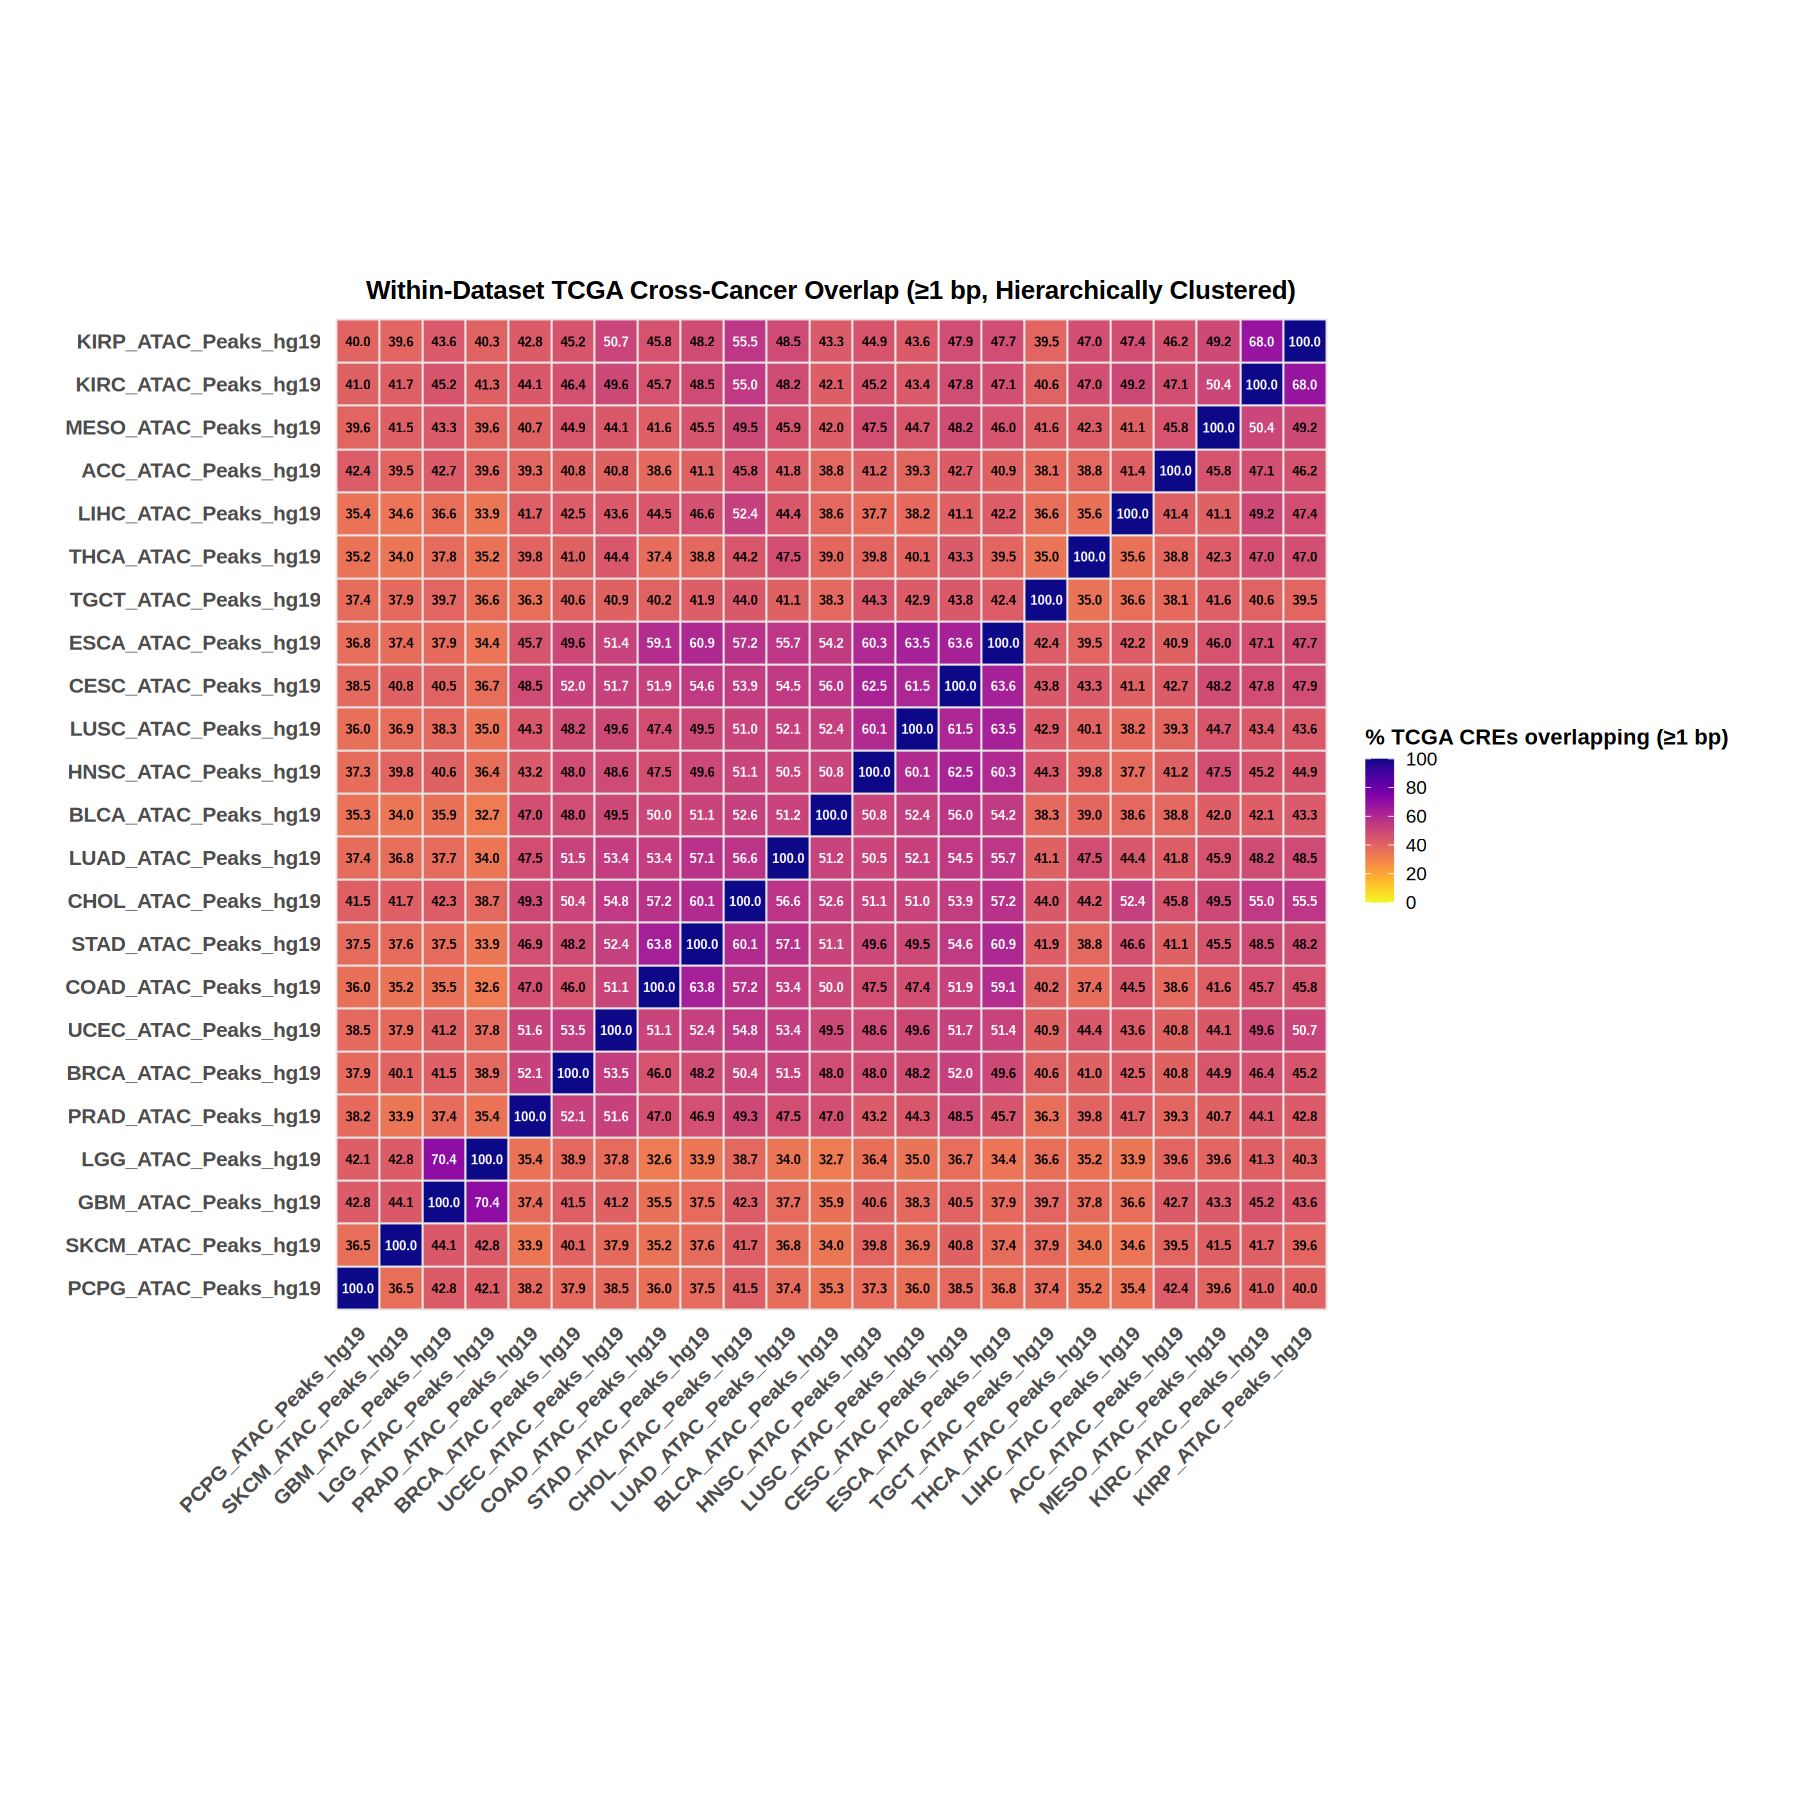

In [1]:
#!/usr/bin/env Rscript
# ===================================================================
# cfDNA CRE Reference – TCGA Within-Dataset Cross-Cancer Overlap
# ===================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(ggplot2)
  library(viridis)
})

# ------------------------------------------------
# Paths
# ------------------------------------------------
tcga_dir <- "../ref/CRE_sites_QC/TCGA_sites_QC2"
out_png  <- "../ref/CRE_sites_Selective/TCGA_within_cross_cancer_overlaps.png"

# ------------------------------------------------
# Files
# ------------------------------------------------
tcga_files <- list.files(tcga_dir, pattern="\\.rds$", full.names=TRUE)
cat(sprintf("Found %d TCGA ATAC files\n", length(tcga_files)))

get_name <- function(path) {
  gsub("_filtered(\\.hg19)?\\.rds$", "", basename(path))
}

# ------------------------------------------------
# Overlap function (≥ 1 bp)
# ------------------------------------------------
compute_overlap_pct <- function(gr1, gr2) {
  hits <- findOverlaps(gr1, gr2, ignore.strand=TRUE)
  if (length(hits) == 0) return(0)
  pct <- 100 * length(unique(subjectHits(hits))) / length(gr2)
  return(pct)
}

# ------------------------------------------------
# Compute all pairwise overlaps
# ------------------------------------------------
overlap_dt <- data.table()
for (i in seq_along(tcga_files)) {
  gr_i <- readRDS(tcga_files[i])
  name_i <- get_name(tcga_files[i])
  cat(sprintf("\nProcessing %s (%d ranges)\n", name_i, length(gr_i)))

  for (j in seq_along(tcga_files)) {
    gr_j <- readRDS(tcga_files[j])
    name_j <- get_name(tcga_files[j])

    pct <- compute_overlap_pct(gr_i, gr_j)
    overlap_dt <- rbind(
      overlap_dt,
      data.table(Cancer1 = name_i,
                 Cancer2 = name_j,
                 pct_overlap = pct)
    )
    cat(sprintf("  %s vs %s → %.2f%% overlap\n", name_i, name_j, pct))
  }
}

# ------------------------------------------------
# Create symmetric matrix
# ------------------------------------------------
mat <- dcast(overlap_dt, Cancer1 ~ Cancer2, value.var="pct_overlap", fill=0)
row_names <- mat$Cancer1
mat_num <- as.matrix(mat[, -1, with=FALSE])
rownames(mat_num) <- row_names
mat_sym <- (mat_num + t(mat_num)) / 2

# ------------------------------------------------
# Hierarchical clustering for ordering
# ------------------------------------------------
order <- hclust(dist(mat_sym))$order
cancers_ordered <- rownames(mat_sym)[order]
overlap_melt <- as.data.table(as.table(mat_sym))
setnames(overlap_melt, c("Cancer1","Cancer2","pct_overlap"))
overlap_melt$Cancer1 <- factor(overlap_melt$Cancer1, levels=cancers_ordered)
overlap_melt$Cancer2 <- factor(overlap_melt$Cancer2, levels=cancers_ordered)

# ------------------------------------------------
# BEAUTIFUL HEATMAP
# ------------------------------------------------
tile_text_size <- 6 * (10 / length(cancers_ordered))
overlap_melt$text_color <- ifelse(overlap_melt$pct_overlap > 50, "white", "black")

gf <- ggplot(overlap_melt, aes(x=Cancer2, y=Cancer1, fill=pct_overlap)) +
  geom_tile(color="grey90", linewidth=0.4) +
  geom_text(aes(label=sprintf("%.1f", pct_overlap), color=text_color),
            size=tile_text_size, fontface="bold") +
  scale_color_identity() +
  scale_fill_viridis(
    name="% TCGA CREs overlapping (≥1 bp)",
    option="C", direction=-1,
    limits=c(0,100),
    breaks=seq(0,100,by=20)
  ) +
  coord_fixed() +
  theme_minimal(base_size=14) +
  theme(
    aspect.ratio=1,
    axis.text.x=element_text(angle=45,hjust=1,vjust=1,size=12,face="bold"),
    axis.text.y=element_text(size=12,face="bold"),
    axis.title=element_blank(),
    panel.grid=element_blank(),
    legend.position="right",
    legend.title=element_text(face="bold",size=13),
    legend.text=element_text(size=11),
    plot.title=element_text(face="bold",size=15,hjust=0.5),
    plot.margin=margin(20,40,20,40)
  ) +
  ggtitle("Within-Dataset TCGA Cross-Cancer Overlap (≥1 bp, Hierarchically Clustered)")

options(repr.plot.width=15, repr.plot.height=15)
print(gf)

# ------------------------------------------------
# Save figure
# ------------------------------------------------
ggsave(filename=out_png, plot=gf, width=15, height=15, dpi=300)
cat(sprintf("\n✅ Heatmap saved to: %s\n", out_png))


## Step 3: Filter within dataset non-specific CRE sites

### DHS

In [8]:
#!/usr/bin/env Rscript
# ===================================================================
# cfDNA CRE Reference – Filter Tissue-Specific DHS / scATAC Sites (Summit ±250 bp, Retain Metadata)
# ===================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(fs)
})

# ------------------------------------------------
# CONFIGURATION
# ------------------------------------------------
mode <- "DHS"   # options: "DHS" or "ATAC"

if (mode == "DHS") {
  input_dir  <- "../ref/CRE_sites_QC/DHS_sites_QC2"
  output_dir <- "../ref/CRE_sites_Selective/DHS_sites_Selective3"
  summit_col <- "summit_hg19"
} else if (mode == "ATAC") {
  input_dir  <- "../ref/CRE_sites_QC/scATAC_sites_QC2"
  output_dir <- "../ref/CRE_sites_Selective/scATAC_sites_Selective3"
  summit_col <- "ATAC_summit_hg19"
} else {
  stop("mode must be either 'DHS' or 'ATAC'")
}

dir_create(output_dir)
cat(sprintf("Running in %s mode\nInput: %s\nOutput: %s\n\n", mode, input_dir, output_dir))

# ------------------------------------------------
# FILES
# ------------------------------------------------
files <- list.files(input_dir, pattern="\\.rds$", full.names=TRUE)
names(files) <- gsub("_filtered(\\.hg19)?\\.rds$", "", basename(files))
cat(sprintf("Found %d %s files\n", length(files), mode))

# ------------------------------------------------
# SUMMIT → GRanges ±250 bp (FIXED)
# ------------------------------------------------
make_summit_gr <- function(gr, summit_col, flank=250) {
  mc <- mcols(gr)
  if (!summit_col %in% names(mc)) {
    stop(sprintf("Missing '%s' column in metadata", summit_col))
  }
  summit_vals <- as.numeric(mc[[summit_col]])
  summit_vals <- summit_vals[!is.na(summit_vals)]  # drop NAs just in case
  starts <- pmax(1, summit_vals - flank)
  ends   <- summit_vals + flank
  GRanges(seqnames=seqnames(gr)[seq_along(starts)],
          ranges=IRanges(start=starts, end=ends))
}

# ------------------------------------------------
# FILTER FUNCTION
# ------------------------------------------------
filter_tissue_specific <- function(name_i, gr_i, all_gr, all_names) {
  hits_total <- logical(length(gr_i))  # TRUE if overlaps any other tissue
  for (j in seq_along(all_gr)) {
    name_j <- all_names[j]
    if (name_i == name_j) next
    hits <- findOverlaps(gr_i, all_gr[[j]], ignore.strand=TRUE)
    if (length(hits) > 0) {
      hits_total[unique(queryHits(hits))] <- TRUE
    }
  }
  keep_idx <- which(!hits_total)
  cat(sprintf("%s: retained %d / %d (%.2f%%) tissue-specific sites\n",
              name_i, length(keep_idx), length(gr_i),
              100 * length(keep_idx) / length(gr_i)))
  return(keep_idx)
}

# ------------------------------------------------
# LOAD ALL SUMMIT WINDOWS
# ------------------------------------------------
all_granges <- list()
for (f in files) {
  gr_full <- readRDS(f)
  gr_summit <- make_summit_gr(gr_full, summit_col, flank=250)
  all_granges[[basename(f)]] <- gr_summit
}
all_names <- names(all_granges)

# ------------------------------------------------
# FILTER EACH FILE (RETAINING METADATA)
# ------------------------------------------------
summary_dt <- data.table(
  Tissue = character(),
  Total  = numeric(),
  Retained = numeric(),
  Removed = numeric(),
  Percent_Retained = numeric(),
  Percent_Removed = numeric()
)

for (i in seq_along(files)) {
  name_i <- all_names[i]
  gr_full <- readRDS(files[i])
  gr_i <- all_granges[[i]]
  
  keep_idx <- filter_tissue_specific(name_i, gr_i, all_granges, all_names)
  
  # Retain same structure & metadata
  gr_filtered <- gr_full[keep_idx]
  
  total_sites <- length(gr_full)
  retained <- length(gr_filtered)
  removed <- total_sites - retained
  pct_retained <- 100 * retained / total_sites
  pct_removed  <- 100 - pct_retained
  
  summary_dt <- rbind(summary_dt, data.table(
    Tissue = name_i,
    Total = total_sites,
    Retained = retained,
    Removed = removed,
    Percent_Retained = pct_retained,
    Percent_Removed = pct_removed
  ))
  
  # Save filtered object
  out_file <- file.path(output_dir, paste0(name_i, "_selective.rds"))
  saveRDS(gr_filtered, out_file)
  cat(sprintf("✅ Saved filtered %s (%d sites) → %s\n\n", name_i, retained, out_file))
}

# ------------------------------------------------
# WRITE SUMMARY QC
# ------------------------------------------------
qc_outfile <- file.path(dirname(output_dir), paste0(mode, "_Selective3_summary_QC.csv"))
fwrite(summary_dt, qc_outfile)
cat("\n📊 Summary QC file saved to:\n", qc_outfile, "\n")

print(summary_dt)
cat("\n✅ All selective CRE files successfully generated and QC summary written.\n")


Running in DHS mode
Input: ../ref/CRE_sites_QC/DHS_sites_QC2
Output: ../ref/CRE_sites_Selective/DHS_sites_Selective3

Found 16 DHS files
Cancer_epithelial_filtered.hg19.rds: retained 44613 / 78475 (56.85%) tissue-specific sites
✅ Saved filtered Cancer_epithelial_filtered.hg19.rds (44613 sites) → ../ref/CRE_sites_Selective/DHS_sites_Selective3/Cancer_epithelial_filtered.hg19.rds_selective.rds

Cardiac_filtered.hg19.rds: retained 23767 / 61601 (38.58%) tissue-specific sites
✅ Saved filtered Cardiac_filtered.hg19.rds (23767 sites) → ../ref/CRE_sites_Selective/DHS_sites_Selective3/Cardiac_filtered.hg19.rds_selective.rds

Digestive_filtered.hg19.rds: retained 31170 / 69646 (44.75%) tissue-specific sites
✅ Saved filtered Digestive_filtered.hg19.rds (31170 sites) → ../ref/CRE_sites_Selective/DHS_sites_Selective3/Digestive_filtered.hg19.rds_selective.rds

Lymphoid_filtered.hg19.rds: retained 56982 / 117700 (48.41%) tissue-specific sites
✅ Saved filtered Lymphoid_filtered.hg19.rds (56982 sites)

## scATAC

In [9]:
#!/usr/bin/env Rscript
# ===================================================================
# cfDNA CRE Reference – Filter Tissue-Specific DHS / scATAC Sites (Summit ±250 bp, Retain Metadata)
# ===================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(fs)
})

# ------------------------------------------------
# CONFIGURATION
# ------------------------------------------------
mode <- "ATAC"   # options: "DHS" or "ATAC"

if (mode == "DHS") {
  input_dir  <- "../ref/CRE_sites_QC/DHS_sites_QC2"
  output_dir <- "../ref/CRE_sites_Selective/DHS_sites_Selective3"
  summit_col <- "summit_hg19"
} else if (mode == "ATAC") {
  input_dir  <- "../ref/CRE_sites_QC/scATAC_sites_QC2"
  output_dir <- "../ref/CRE_sites_Selective/scATAC_sites_Selective3"
  summit_col <- "ATAC_summit_hg19"
} else {
  stop("mode must be either 'DHS' or 'ATAC'")
}

dir_create(output_dir)
cat(sprintf("Running in %s mode\nInput: %s\nOutput: %s\n\n", mode, input_dir, output_dir))

# ------------------------------------------------
# FILES
# ------------------------------------------------
files <- list.files(input_dir, pattern="\\.rds$", full.names=TRUE)
names(files) <- gsub("_filtered(\\.hg19)?\\.rds$", "", basename(files))
cat(sprintf("Found %d %s files\n", length(files), mode))

# ------------------------------------------------
# SUMMIT → GRanges ±250 bp (FIXED)
# ------------------------------------------------
make_summit_gr <- function(gr, summit_col, flank=250) {
  mc <- mcols(gr)
  if (!summit_col %in% names(mc)) {
    stop(sprintf("Missing '%s' column in metadata", summit_col))
  }
  summit_vals <- as.numeric(mc[[summit_col]])
  summit_vals <- summit_vals[!is.na(summit_vals)]  # drop NAs just in case
  starts <- pmax(1, summit_vals - flank)
  ends   <- summit_vals + flank
  GRanges(seqnames=seqnames(gr)[seq_along(starts)],
          ranges=IRanges(start=starts, end=ends))
}

# ------------------------------------------------
# FILTER FUNCTION
# ------------------------------------------------
filter_tissue_specific <- function(name_i, gr_i, all_gr, all_names) {
  hits_total <- logical(length(gr_i))  # TRUE if overlaps any other tissue
  for (j in seq_along(all_gr)) {
    name_j <- all_names[j]
    if (name_i == name_j) next
    hits <- findOverlaps(gr_i, all_gr[[j]], ignore.strand=TRUE)
    if (length(hits) > 0) {
      hits_total[unique(queryHits(hits))] <- TRUE
    }
  }
  keep_idx <- which(!hits_total)
  cat(sprintf("%s: retained %d / %d (%.2f%%) tissue-specific sites\n",
              name_i, length(keep_idx), length(gr_i),
              100 * length(keep_idx) / length(gr_i)))
  return(keep_idx)
}

# ------------------------------------------------
# LOAD ALL SUMMIT WINDOWS
# ------------------------------------------------
all_granges <- list()
for (f in files) {
  gr_full <- readRDS(f)
  gr_summit <- make_summit_gr(gr_full, summit_col, flank=250)
  all_granges[[basename(f)]] <- gr_summit
}
all_names <- names(all_granges)

# ------------------------------------------------
# FILTER EACH FILE (RETAINING METADATA)
# ------------------------------------------------
summary_dt <- data.table(
  Tissue = character(),
  Total  = numeric(),
  Retained = numeric(),
  Removed = numeric(),
  Percent_Retained = numeric(),
  Percent_Removed = numeric()
)

for (i in seq_along(files)) {
  name_i <- all_names[i]
  gr_full <- readRDS(files[i])
  gr_i <- all_granges[[i]]
  
  keep_idx <- filter_tissue_specific(name_i, gr_i, all_granges, all_names)
  
  # Retain same structure & metadata
  gr_filtered <- gr_full[keep_idx]
  
  total_sites <- length(gr_full)
  retained <- length(gr_filtered)
  removed <- total_sites - retained
  pct_retained <- 100 * retained / total_sites
  pct_removed  <- 100 - pct_retained
  
  summary_dt <- rbind(summary_dt, data.table(
    Tissue = name_i,
    Total = total_sites,
    Retained = retained,
    Removed = removed,
    Percent_Retained = pct_retained,
    Percent_Removed = pct_removed
  ))
  
  # Save filtered object
  out_file <- file.path(output_dir, paste0(name_i, "_selective.rds"))
  saveRDS(gr_filtered, out_file)
  cat(sprintf("✅ Saved filtered %s (%d sites) → %s\n\n", name_i, retained, out_file))
}

# ------------------------------------------------
# WRITE SUMMARY QC
# ------------------------------------------------
qc_outfile <- file.path(dirname(output_dir), paste0(mode, "_Selective3_summary_QC.csv"))
fwrite(summary_dt, qc_outfile)
cat("\n📊 Summary QC file saved to:\n", qc_outfile, "\n")

print(summary_dt)
cat("\n✅ All selective CRE files successfully generated and QC summary written.\n")


Running in ATAC mode
Input: ../ref/CRE_sites_QC/scATAC_sites_QC2
Output: ../ref/CRE_sites_Selective/scATAC_sites_Selective3

Found 20 ATAC files
Adrenal_Cortical_filtered.hg19.rds: retained 19413 / 21000 (92.44%) tissue-specific sites
✅ Saved filtered Adrenal_Cortical_filtered.hg19.rds (19413 sites) → ../ref/CRE_sites_Selective/scATAC_sites_Selective3/Adrenal_Cortical_filtered.hg19.rds_selective.rds

Adult_Stromal_filtered.hg19.rds: retained 38810 / 41771 (92.91%) tissue-specific sites
✅ Saved filtered Adult_Stromal_filtered.hg19.rds (38810 sites) → ../ref/CRE_sites_Selective/scATAC_sites_Selective3/Adult_Stromal_filtered.hg19.rds_selective.rds

Cardiomyocyte_filtered.hg19.rds: retained 11117 / 11901 (93.41%) tissue-specific sites
✅ Saved filtered Cardiomyocyte_filtered.hg19.rds (11117 sites) → ../ref/CRE_sites_Selective/scATAC_sites_Selective3/Cardiomyocyte_filtered.hg19.rds_selective.rds

Endothelial_filtered.hg19.rds: retained 29848 / 32255 (92.54%) tissue-specific sites
✅ Saved fil

## TCGA

In [2]:
#!/usr/bin/env Rscript
# ===================================================================
# cfDNA CRE Reference – TCGA ATAC Within-Dataset Cancer-Specific Sites (Range-Based)
# ===================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(fs)
})

# ------------------------------------------------
# CONFIGURATION
# ------------------------------------------------
input_dir  <- "../ref/CRE_sites_QC/TCGA_sites_QC2"
output_dir <- "../ref/CRE_sites_Selective/TCGA_sites_Selective3"
dir_create(output_dir)

cat(sprintf("Running TCGA selective filtering\nInput: %s\nOutput: %s\n\n", input_dir, output_dir))

# ------------------------------------------------
# FILES
# ------------------------------------------------
files <- list.files(input_dir, pattern="\\.rds$", full.names=TRUE)
names(files) <- gsub("_filtered(\\.hg19)?\\.rds$", "", basename(files))
cat(sprintf("Found %d TCGA cancer files\n", length(files)))

# ------------------------------------------------
# FILTER FUNCTION
# ------------------------------------------------
filter_cancer_specific <- function(name_i, gr_i, all_gr, all_names) {
  hits_total <- logical(length(gr_i))  # TRUE if overlaps any other cancer
  for (j in seq_along(all_gr)) {
    name_j <- all_names[j]
    if (name_i == name_j) next
    hits <- findOverlaps(gr_i, all_gr[[j]], ignore.strand=TRUE)
    if (length(hits) > 0) {
      hits_total[unique(queryHits(hits))] <- TRUE
    }
  }
  keep_idx <- which(!hits_total)
  cat(sprintf("%s: retained %d / %d (%.2f%%) cancer-specific peaks\n",
              name_i, length(keep_idx), length(gr_i),
              100 * length(keep_idx) / length(gr_i)))
  return(keep_idx)
}

# ------------------------------------------------
# LOAD ALL PEAK RANGES
# ------------------------------------------------
all_granges <- list()
for (f in files) {
  gr_full <- readRDS(f)
  gr_ranges <- gr_full  # use full range instead of summit ± window
  all_granges[[basename(f)]] <- gr_ranges
}
all_names <- names(all_granges)

# ------------------------------------------------
# FILTER EACH FILE (RETAINING METADATA)
# ------------------------------------------------
summary_dt <- data.table(
  Cancer = character(),
  Total  = numeric(),
  Retained = numeric(),
  Removed = numeric(),
  Percent_Retained = numeric(),
  Percent_Removed = numeric()
)

for (i in seq_along(files)) {
  name_i <- all_names[i]
  gr_full <- readRDS(files[i])
  gr_i <- all_granges[[i]]

  keep_idx <- filter_cancer_specific(name_i, gr_i, all_granges, all_names)

  # Retain same structure & metadata
  gr_filtered <- gr_full[keep_idx]

  total_sites <- length(gr_full)
  retained <- length(gr_filtered)
  removed <- total_sites - retained
  pct_retained <- 100 * retained / total_sites
  pct_removed  <- 100 - pct_retained

  summary_dt <- rbind(summary_dt, data.table(
    Cancer = name_i,
    Total = total_sites,
    Retained = retained,
    Removed = removed,
    Percent_Retained = pct_retained,
    Percent_Removed = pct_removed
  ))

  # Save cancer-specific object
  out_file <- file.path(output_dir, paste0(name_i, "_selective.rds"))
  saveRDS(gr_filtered, out_file)
  cat(sprintf("✅ Saved filtered %s (%d sites) → %s\n\n", name_i, retained, out_file))
}

# ------------------------------------------------
# WRITE SUMMARY QC
# ------------------------------------------------
qc_outfile <- file.path(dirname(output_dir), "TCGA_Selective3_summary_QC.csv")
fwrite(summary_dt, qc_outfile)
cat("\n📊 Summary QC file saved to:\n", qc_outfile, "\n")

# ------------------------------------------------
# PAN-CANCER (SHARED) PEAKS
# ------------------------------------------------
cat("\n--- Identifying pan-cancer (shared) peaks ---\n")

# Combine all GRanges
gr_all <- all_granges[[1]]
for (k in 2:length(all_granges)) {
  gr_all <- c(gr_all, all_granges[[k]])
}

# Find peaks shared by *all* cancers
shared_hits <- reduce(gr_all)  # collapse overlapping peaks
# Determine which reduced ranges are present in every cancer
shared_idx <- rep(TRUE, length(shared_hits))

for (i in seq_along(all_granges)) {
  overlaps <- findOverlaps(shared_hits, all_granges[[i]], ignore.strand=TRUE)
  in_cancer <- unique(queryHits(overlaps))
  shared_idx[!(seq_along(shared_idx) %in% in_cancer)] <- FALSE
}

shared_peaks <- shared_hits[shared_idx]
cat(sprintf("✅ Found %d pan-cancer shared peaks across all %d cancers\n",
            length(shared_peaks), length(all_granges)))

# Save pan-cancer shared peaks
out_shared <- file.path(output_dir, "TCGA_pan_cancer_shared_peaks.rds")
saveRDS(shared_peaks, out_shared)
cat(sprintf("✅ Saved pan-cancer shared peaks → %s\n", out_shared))

cat("\n✅ All TCGA selective and pan-cancer peak files successfully generated.\n")


Warning message:
“package ‘fs’ was built under R version 4.3.3”


Running TCGA selective filtering
Input: ../ref/CRE_sites_QC/TCGA_sites_QC2
Output: ../ref/CRE_sites_Selective/TCGA_sites_Selective3

Found 23 TCGA cancer files
ACC_ATAC_Peaks_hg19_filtered.hg19.rds: retained 8187 / 51645 (15.85%) cancer-specific peaks
✅ Saved filtered ACC_ATAC_Peaks_hg19_filtered.hg19.rds (8187 sites) → ../ref/CRE_sites_Selective/TCGA_sites_Selective3/ACC_ATAC_Peaks_hg19_filtered.hg19.rds_selective.rds

BLCA_ATAC_Peaks_hg19_filtered.hg19.rds: retained 7368 / 62412 (11.81%) cancer-specific peaks
✅ Saved filtered BLCA_ATAC_Peaks_hg19_filtered.hg19.rds (7368 sites) → ../ref/CRE_sites_Selective/TCGA_sites_Selective3/BLCA_ATAC_Peaks_hg19_filtered.hg19.rds_selective.rds

BRCA_ATAC_Peaks_hg19_filtered.hg19.rds: retained 26753 / 128872 (20.76%) cancer-specific peaks
✅ Saved filtered BRCA_ATAC_Peaks_hg19_filtered.hg19.rds (26753 sites) → ../ref/CRE_sites_Selective/TCGA_sites_Selective3/BRCA_ATAC_Peaks_hg19_filtered.hg19.rds_selective.rds

CESC_ATAC_Peaks_hg19_filtered.hg19.rds:

In [26]:
#!/usr/bin/env Rscript
# ===================================================================
# cfDNA CRE Reference – TCGA ATAC Within-Dataset Cancer-Specific Sites (Range-Based)
# Adds 'score' column to pan-cancer shared peaks (max across cancers)
# ===================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(fs)
})

# ------------------------------------------------
# CONFIGURATION
# ------------------------------------------------
input_dir  <- "../ref/CRE_sites_QC/TCGA_sites_QC2"
output_dir <- "../ref/CRE_sites_Selective/TCGA_sites_Selective3"
dir_create(output_dir)

cat(sprintf("Running TCGA selective filtering\nInput: %s\nOutput: %s\n\n",
            input_dir, output_dir))

# ------------------------------------------------
# FILES
# ------------------------------------------------
files <- list.files(input_dir, pattern = "\\.rds$", full.names = TRUE)
# Use clean cancer names (strip suffixes) as list names
clean_names <- gsub("_filtered(\\.hg19)?\\.rds$", "", basename(files))
names(files) <- clean_names
cat(sprintf("Found %d TCGA cancer files\n", length(files)))

# ------------------------------------------------
# LOAD ALL PEAK RANGES (consistent naming)
# ------------------------------------------------
all_granges <- vector("list", length(files))
names(all_granges) <- names(files)

for (i in seq_along(files)) {
  nm <- names(files)[i]
  gr_full <- readRDS(files[i])
  # Use full ranges (not summit windows)
  all_granges[[nm]] <- gr_full
}

all_names <- names(all_granges)

# ------------------------------------------------
# FILTER FUNCTION (cancer-selective within dataset)
# ------------------------------------------------
filter_cancer_specific <- function(name_i, gr_i, all_gr, all_names) {
  hits_total <- logical(length(gr_i))  # TRUE if overlaps any other cancer
  for (j in seq_along(all_gr)) {
    if (name_i == all_names[j]) next
    hits <- findOverlaps(gr_i, all_gr[[j]], ignore.strand = TRUE)
    if (length(hits)) {
      hits_total[unique(queryHits(hits))] <- TRUE
    }
  }
  keep_idx <- which(!hits_total)
  cat(sprintf("%s: retained %d / %d (%.2f%%) cancer-specific peaks\n",
              name_i, length(keep_idx), length(gr_i),
              100 * length(keep_idx) / length(gr_i)))
  keep_idx
}

# ------------------------------------------------
# FILTER EACH FILE (RETAIN METADATA) + WRITE PER-CANCER OUTPUTS
# ------------------------------------------------
summary_dt <- data.table(
  Cancer = character(), Total = integer(), Retained = integer(),
  Removed = integer(), Percent_Retained = numeric(), Percent_Removed = numeric()
)

for (i in seq_along(files)) {
  name_i <- all_names[i]
  gr_full <- all_granges[[i]]
  if (!length(gr_full)) next

  keep_idx <- filter_cancer_specific(name_i, gr_full, all_granges, all_names)
  gr_filtered <- gr_full[keep_idx]

  total_sites <- length(gr_full)
  retained    <- length(gr_filtered)
  removed     <- total_sites - retained
  pct_retained <- if (total_sites > 0) 100 * retained / total_sites else 0
  pct_removed  <- 100 - pct_retained

  summary_dt <- rbind(summary_dt, data.table(
    Cancer = name_i,
    Total = total_sites,
    Retained = retained,
    Removed = removed,
    Percent_Retained = pct_retained,
    Percent_Removed  = pct_removed
  ), fill = TRUE)

  out_file <- file.path(output_dir, paste0(name_i, "_selective.rds"))
  saveRDS(gr_filtered, out_file)
  cat(sprintf("✅ Saved filtered %s (%d sites) → %s\n\n", name_i, retained, out_file))
}

# ------------------------------------------------
# WRITE SUMMARY QC
# ------------------------------------------------
qc_outfile <- file.path(dirname(output_dir), "TCGA_Selective3_summary_QC.csv")
fwrite(summary_dt, qc_outfile)
cat("\n📊 Summary QC file saved to:\n", qc_outfile, "\n")

# ------------------------------------------------
# PAN-CANCER (SHARED) PEAKS + MAX SCORE
# ------------------------------------------------
cat("\n--- Identifying pan-cancer (shared) peaks ---\n")

# Combine all GRanges across cancers (flatten safely)
gr_all <- do.call(c, all_granges)
if (!inherits(gr_all, "GRanges")) gr_all <- unlist(GRangesList(gr_all))

# Reduce to merged regions (candidate shared peaks)
reduced_all <- reduce(gr_all, ignore.strand = TRUE)

# Determine which reduced ranges occur in *every* cancer set
shared_idx <- rep(TRUE, length(reduced_all))
for (i in seq_along(all_granges)) {
  overlaps <- findOverlaps(reduced_all, all_granges[[i]], ignore.strand = TRUE)
  in_cancer <- unique(queryHits(overlaps))
  shared_idx[!(seq_along(shared_idx) %in% in_cancer)] <- FALSE
}

shared_peaks <- reduced_all[shared_idx]
cat(sprintf("✅ Found %d pan-cancer shared peaks across all %d cancers\n",
            length(shared_peaks), length(all_granges)))

# ---------- Add highest score across all cancers ----------
cat("Adding max score across all tumor types...\n")

# Gather all scored GRanges in one object
scored_list <- list()
for (nm in all_names) {
  gr_tmp <- all_granges[[nm]]
  if (!"score" %in% names(mcols(gr_tmp))) next
  mcols(gr_tmp)$Cancer <- nm
  scored_list[[length(scored_list) + 1]] <- gr_tmp
}

if (length(scored_list) == 0) {
  warning("No 'score' column found in any cancer file; writing shared peaks without score.")
  out_shared <- file.path(output_dir, "TCGA_pan_cancer_shared_peaks.rds")
  saveRDS(shared_peaks, out_shared)
  cat(sprintf("⚠️ Saved pan-cancer shared peaks (no score) → %s\n", out_shared))
} else {
  gr_with_scores <- do.call(c, scored_list)
  if (!inherits(gr_with_scores, "GRanges")) gr_with_scores <- unlist(GRangesList(gr_with_scores))

  # Overlap shared peaks with scored peaks, then take per-shared max(score)
  hits <- findOverlaps(shared_peaks, gr_with_scores, ignore.strand = TRUE)

  if (length(hits) > 0) {
    hit_dt <- data.table(
      shared_idx = queryHits(hits),
      score = gr_with_scores$score[subjectHits(hits)]
    )
    max_scores <- hit_dt[, .(score = max(score, na.rm = TRUE)), by = shared_idx]

    # Initialize and assign
    shared_peaks$score <- NA_real_
    shared_peaks$score[max_scores$shared_idx] <- max_scores$score

    cat("✅ Added 'score' column to shared peaks (max across cancers)\n")

    out_shared <- file.path(output_dir, "TCGA_pan_cancer_shared_peaks_withscore.rds")
    saveRDS(shared_peaks, out_shared)
    cat(sprintf("✅ Saved pan-cancer shared peaks with score → %s\n", out_shared))
  } else {
    out_shared <- file.path(output_dir, "TCGA_pan_cancer_shared_peaks.rds")
    saveRDS(shared_peaks, out_shared)
    cat(sprintf("⚠️ No overlaps to assign scores; saved without score → %s\n", out_shared))
  }
}

cat("\n✅ All TCGA selective and pan-cancer peak files successfully generated.\n")


Running TCGA selective filtering
Input: ../ref/CRE_sites_QC/TCGA_sites_QC2
Output: ../ref/CRE_sites_Selective/TCGA_sites_Selective3

Found 23 TCGA cancer files
ACC_ATAC_Peaks_hg19: retained 8187 / 51645 (15.85%) cancer-specific peaks
✅ Saved filtered ACC_ATAC_Peaks_hg19 (8187 sites) → ../ref/CRE_sites_Selective/TCGA_sites_Selective3/ACC_ATAC_Peaks_hg19_selective.rds

BLCA_ATAC_Peaks_hg19: retained 7368 / 62412 (11.81%) cancer-specific peaks
✅ Saved filtered BLCA_ATAC_Peaks_hg19 (7368 sites) → ../ref/CRE_sites_Selective/TCGA_sites_Selective3/BLCA_ATAC_Peaks_hg19_selective.rds

BRCA_ATAC_Peaks_hg19: retained 26753 / 128872 (20.76%) cancer-specific peaks
✅ Saved filtered BRCA_ATAC_Peaks_hg19 (26753 sites) → ../ref/CRE_sites_Selective/TCGA_sites_Selective3/BRCA_ATAC_Peaks_hg19_selective.rds

CESC_ATAC_Peaks_hg19: retained 297 / 30154 (0.98%) cancer-specific peaks
✅ Saved filtered CESC_ATAC_Peaks_hg19 (297 sites) → ../ref/CRE_sites_Selective/TCGA_sites_Selective3/CESC_ATAC_Peaks_hg19_select

### TCGA Organ level

In [31]:
#!/usr/bin/env Rscript
# ===================================================================
# cfDNA CRE Reference – Organ / Organ-System Selective CREs (TCGA v3)
# Adds 'score' column to organ-selective and pan-organ shared peaks
# Robust handling of NULL, list, and missing scores
# ===================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(fs)
})

# ------------------------------------------------
# 1. Directories
# ------------------------------------------------
input_dir  <- "../ref/CRE_sites_QC/TCGA_sites_QC2"
output_dir <- "../ref/CRE_sites_Selective/TCGA_Organ_Selective_v3"
dir_create(output_dir)
cat(sprintf("Input: %s\nOutput: %s\n\n", input_dir, output_dir))

# ------------------------------------------------
# 2. Organ system groupings
# ------------------------------------------------
organ_groups <- list(
  Brain   = c("GBM", "LGG"),
  Lung    = c("LUAD", "LUSC"),
  GI      = c("COAD", "STAD", "ESCA", "CHOL"),
  Kidney  = c("KIRC", "KIRP"),
  Breast  = c("BRCA"),
  Gyn     = c("CESC", "UCEC"),
  Endocrine = c("THCA", "ACC", "PCPG"),
  Prostate = c("PRAD"),
  Bladder  = c("BLCA"),
  Ovary    = c("OV"),
  Liver    = c("LIHC"),
  Germ     = c("TGCT"),
  Skin     = c("SKCM"),
  Mesothelium = c("MESO")
)
cat("Organ system groups defined:\n")
print(organ_groups)

# ------------------------------------------------
# 3. Load TCGA CREs
# ------------------------------------------------
tcga_files <- list.files(input_dir, pattern = "\\.rds$", full.names = TRUE)
names(tcga_files) <- gsub("_filtered(\\.hg19)?\\.rds$", "", basename(tcga_files))
cat(sprintf("\nFound %d TCGA cancer CRE files\n", length(tcga_files)))

all_gr <- list()
for (f in tcga_files) {
  nm <- gsub("_ATAC.*", "", basename(f))
  gr <- readRDS(f)
  if (!inherits(gr, "GRanges")) next
  all_gr[[nm]] <- gr
}

# ------------------------------------------------
# 4. Merge cancers into organ-level GRanges
# ------------------------------------------------
organ_granges <- list()
for (org in names(organ_groups)) {
  cancers <- organ_groups[[org]]
  existing <- cancers[cancers %in% names(all_gr)]
  if (length(existing) == 0) {
    warning(sprintf("Skipping organ %s (no available cancers)", org))
    next
  }

  gr_list <- Filter(Negate(is.null), all_gr[existing])
  if (length(gr_list) == 0) next

  merged <- suppressWarnings(do.call(c, gr_list))
  if (!inherits(merged, "GRanges")) merged <- unlist(GRangesList(gr_list))
  merged <- merged[width(merged) > 0]
  merged <- reduce(merged, ignore.strand = TRUE)

  organ_granges[[org]] <- merged
  cat(sprintf("%-14s: merged %d cancers → %d unique CREs\n",
              org, length(existing), length(merged)))
}

# ------------------------------------------------
# 5. Organ-selective filtering
# ------------------------------------------------
filter_organ_specific <- function(name_i, gr_i, all_gr, all_names) {
  hits_total <- logical(length(gr_i))
  for (j in seq_along(all_gr)) {
    if (name_i == all_names[j]) next
    hits <- findOverlaps(gr_i, all_gr[[j]], ignore.strand = TRUE)
    if (length(hits)) hits_total[unique(queryHits(hits))] <- TRUE
  }
  keep_idx <- which(!hits_total)
  cat(sprintf("%s: retained %d / %d (%.2f%%) organ-selective peaks\n",
              name_i, length(keep_idx), length(gr_i),
              100 * length(keep_idx) / length(gr_i)))
  keep_idx
}

summary_dt <- data.table()

for (i in seq_along(organ_granges)) {
  org_i <- names(organ_granges)[i]
  gr_i  <- organ_granges[[i]]
  if (!inherits(gr_i, "GRanges") || length(gr_i) == 0) next

  keep_idx <- filter_organ_specific(org_i, gr_i, organ_granges, names(organ_granges))
  gr_filtered <- gr_i[keep_idx]

  # ---- Add max score within this organ ----
  cancers_in_org <- organ_groups[[org_i]]
  cancers_in_org <- cancers_in_org[cancers_in_org %in% names(all_gr)]

  score_sources <- lapply(cancers_in_org, function(cn) {
    gr_tmp <- all_gr[[cn]]
    if (!"score" %in% names(mcols(gr_tmp))) return(NULL)
    gr_tmp
  })
  score_sources <- Filter(Negate(is.null), score_sources)

  gr_filtered$score <- NA_real_
  if (length(score_sources) > 0) {
    gr_scored <- suppressWarnings(do.call(c, score_sources))
    if (!inherits(gr_scored, "GRanges")) gr_scored <- unlist(GRangesList(score_sources))
    hits <- findOverlaps(gr_filtered, gr_scored, ignore.strand = TRUE)
    if (length(hits)) {
      dt <- data.table(q = queryHits(hits),
                       s = gr_scored$score[subjectHits(hits)])
      sc_max <- dt[, .(score = max(s, na.rm = TRUE)), by = q]
      gr_filtered$score[sc_max$q] <- sc_max$score
    }
  }

  out_file <- file.path(output_dir, paste0(org_i, "_organ_selective.rds"))
  saveRDS(gr_filtered, out_file)
  cat(sprintf("✅ Saved %s (%d peaks) → %s\n", org_i, length(gr_filtered), out_file))

  summary_dt <- rbind(summary_dt, data.table(
    Organ = org_i,
    Total = length(gr_i),
    Retained = length(gr_filtered),
    Percent_Retained = round(100 * length(gr_filtered) / length(gr_i), 2)
  ))
}

# ------------------------------------------------
# 6. Identify pan-organ shared peaks
# ------------------------------------------------
cat("\n--- Identifying pan-organ shared peaks ---\n")

non_empty_orgs <- Filter(function(x) inherits(x, "GRanges") && length(x) > 0, organ_granges)
if (length(non_empty_orgs) == 0) stop("❌ No valid organ GRanges to combine.")

gr_all_org <- suppressWarnings(do.call(c, non_empty_orgs))
if (!inherits(gr_all_org, "GRanges")) gr_all_org <- unlist(GRangesList(non_empty_orgs))
gr_all_org <- gr_all_org[width(gr_all_org) > 0]
shared_hits <- reduce(gr_all_org, ignore.strand = TRUE)

shared_idx <- rep(TRUE, length(shared_hits))
for (i in seq_along(non_empty_orgs)) {
  overlaps <- findOverlaps(shared_hits, non_empty_orgs[[i]], ignore.strand = TRUE)
  in_org <- unique(queryHits(overlaps))
  shared_idx[!(seq_along(shared_idx) %in% in_org)] <- FALSE
}
shared_peaks <- shared_hits[shared_idx]
cat(sprintf("✅ Found %d pan-organ shared peaks across %d valid organs\n",
            length(shared_peaks), length(non_empty_orgs)))

# ---- Add max score across all organs ----
cat("Adding max score across all organ groups...\n")
score_sources_all <- Filter(function(gr) "score" %in% names(mcols(gr)), all_gr)
score_sources_all <- Filter(Negate(is.null), score_sources_all)
shared_peaks$score <- NA_real_

if (length(score_sources_all) > 0) {
  gr_with_scores <- suppressWarnings(do.call(c, score_sources_all))
  if (!inherits(gr_with_scores, "GRanges")) gr_with_scores <- unlist(GRangesList(score_sources_all))
  hits <- findOverlaps(shared_peaks, gr_with_scores, ignore.strand = TRUE)
  if (length(hits)) {
    dt <- data.table(q = queryHits(hits),
                     s = gr_with_scores$score[subjectHits(hits)])
    sc_max <- dt[, .(score = max(s, na.rm = TRUE)), by = q]
    shared_peaks$score[sc_max$q] <- sc_max$score
    cat("✅ Added 'score' column to shared peaks (max across organs)\n")
  } else {
    warning("No overlaps for assigning pan-organ scores.")
  }
} else {
  warning("No score columns found in any cancer file.")
}

out_shared <- file.path(output_dir, "TCGA_pan_organ_shared_peaks_withscore.rds")
saveRDS(shared_peaks, out_shared)
cat(sprintf("✅ Saved pan-organ shared peaks with score → %s\n", out_shared))

# ------------------------------------------------
# 7. QC Summary
# ------------------------------------------------
qc_outfile <- file.path(output_dir, "TCGA_Organ_Selective_summary_QC.csv")
fwrite(summary_dt, qc_outfile)
cat("\n📊 Summary QC file saved to:", qc_outfile, "\n")
cat("\n✅ All organ-level selective and pan-organ CRE files successfully generated.\n")


Input: ../ref/CRE_sites_QC/TCGA_sites_QC2
Output: ../ref/CRE_sites_Selective/TCGA_Organ_Selective_v3

Organ system groups defined:
$Brain
[1] "GBM" "LGG"

$Lung
[1] "LUAD" "LUSC"

$GI
[1] "COAD" "STAD" "ESCA" "CHOL"

$Kidney
[1] "KIRC" "KIRP"

$Breast
[1] "BRCA"

$Gyn
[1] "CESC" "UCEC"

$Endocrine
[1] "THCA" "ACC"  "PCPG"

$Prostate
[1] "PRAD"

$Bladder
[1] "BLCA"

$Ovary
[1] "OV"

$Liver
[1] "LIHC"

$Germ
[1] "TGCT"

$Skin
[1] "SKCM"

$Mesothelium
[1] "MESO"


Found 23 TCGA cancer CRE files
Brain         : merged 2 cancers → 56243 unique CREs
Lung          : merged 2 cancers → 109928 unique CREs
GI            : merged 4 cancers → 122395 unique CREs
Kidney        : merged 2 cancers → 89295 unique CREs
Breast        : merged 1 cancers → 128574 unique CREs
Gyn           : merged 2 cancers → 68759 unique CREs
Endocrine     : merged 3 cancers → 108290 unique CREs
Prostate      : merged 1 cancers → 64234 unique CREs
Bladder       : merged 1 cancers → 62311 unique CREs


Warning message in eval(expr, envir, enclos):
“Skipping organ Ovary (no available cancers)”


Liver         : merged 1 cancers → 70843 unique CREs
Germ          : merged 1 cancers → 40659 unique CREs
Skin          : merged 1 cancers → 59195 unique CREs
Mesothelium   : merged 1 cancers → 44339 unique CREs
Brain: retained 11470 / 56243 (20.39%) organ-selective peaks
✅ Saved Brain (11470 peaks) → ../ref/CRE_sites_Selective/TCGA_Organ_Selective_v3/Brain_organ_selective.rds
Lung: retained 16505 / 109928 (15.01%) organ-selective peaks
✅ Saved Lung (16505 peaks) → ../ref/CRE_sites_Selective/TCGA_Organ_Selective_v3/Lung_organ_selective.rds
GI: retained 21844 / 122395 (17.85%) organ-selective peaks
✅ Saved GI (21844 peaks) → ../ref/CRE_sites_Selective/TCGA_Organ_Selective_v3/GI_organ_selective.rds
Kidney: retained 12527 / 89295 (14.03%) organ-selective peaks
✅ Saved Kidney (12527 peaks) → ../ref/CRE_sites_Selective/TCGA_Organ_Selective_v3/Kidney_organ_selective.rds
Breast: retained 27157 / 128574 (21.12%) organ-selective peaks
✅ Saved Breast (27157 peaks) → ../ref/CRE_sites_Selective/TC

### Cancer vs. Healthy ATAC Overlaps

In [24]:
#!/usr/bin/env Rscript
# ===================================================================
# TCGA (cancer) × scATAC (healthy) overlap analysis and heatmaps
# Outputs to ../ref/CRE_sites_Selective/TCGA_sites_Selective3/
# ===================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(ggplot2)
  library(viridis)
  library(fs)
})

# ------------------------------------------------
# 1. Directories
# ------------------------------------------------
tcga_dir   <- "../ref/CRE_sites_QC/TCGA_sites_QC2"       # TCGA filtered CREs
scatac_dir <- "../ref/CRE_sites_QC/scATAC_sites_QC2"     # scATAC filtered CREs
out_dir    <- "../ref/CRE_sites_Selective/TCGA_sites_Selective3"

cat(sprintf("Input TCGA: %s\nInput scATAC: %s\nOutput: %s\n\n",
            tcga_dir, scatac_dir, out_dir))

# ------------------------------------------------
# 2. Helper functions
# ------------------------------------------------
msg <- function(...) cat(sprintf("[%s] ", format(Sys.time(), "%H:%M:%S")),
                         sprintf(...), "\n")

get_name <- function(path)
  gsub("_filtered(\\.hg19)?\\.rds$", "", basename(path))

reduce_if_needed <- function(gr) {
  if (!inherits(gr, "GRanges")) gr <- unlist(GRangesList(gr))
  reduce(gr, ignore.strand = TRUE)
}

# % of B peaks overlapped by A (≥1 bp)
pct_A_covers_B <- function(A, B) {
  if (length(A) == 0 || length(B) == 0) return(0)
  hits <- findOverlaps(B, A, ignore.strand = TRUE)
  if (length(hits) == 0) return(0)
  100 * length(unique(queryHits(hits))) / length(B)
}

# Safe bp-based Jaccard using GRanges width
jaccard_bp <- function(A, B) {
  if (length(A) == 0 && length(B) == 0) return(NA_real_)
  if (length(A) == 0 || length(B) == 0)  return(0)
  inter <- suppressWarnings(intersect(A, B, ignore.strand = TRUE))
  uni   <- suppressWarnings(union(A, B, ignore.strand = TRUE))
  if (length(uni) == 0) return(0)
  sum(width(inter)) / sum(width(uni))
}

plot_heatmap <- function(mat, title, legend_lab, out_png) {
  # Cluster ordering
  if (nrow(mat) > 1 && ncol(mat) > 1) {
    r_ord <- hclust(dist(mat))$order
    c_ord <- hclust(dist(t(mat)))$order
  } else { r_ord <- seq_len(nrow(mat)); c_ord <- seq_len(ncol(mat)) }

  mat_ord <- mat[r_ord, c_ord, drop = FALSE]
  df <- as.data.table(as.table(mat_ord))
  setnames(df, c("Cancer","CellType","value"))

  fill_limits <- if (grepl("%", legend_lab)) c(0, 100) else c(0, 1)

  gg <- ggplot(df, aes(CellType, Cancer, fill = value)) +
    geom_tile(color="grey90", linewidth=0.4) +
    geom_text(aes(label = if (grepl("%", legend_lab))
                    sprintf("%.1f", value)
                  else sprintf("%.2f", value)),
              size = 3.2, fontface = "bold") +
    scale_fill_viridis(name = legend_lab, option = "C",
                       direction = -1, limits = fill_limits) +
    coord_fixed() +
    theme_minimal(base_size = 13) +
    theme(
      axis.text.x = element_text(angle=45, hjust=1, vjust=1, face="bold"),
      axis.text.y = element_text(face="bold"),
      axis.title  = element_blank(),
      panel.grid  = element_blank(),
      plot.title  = element_text(face="bold", hjust=0.5, size=15),
      plot.margin = margin(16, 28, 16, 28)
    ) +
    ggtitle(title)

  ggsave(out_png, gg,
         width = max(10, ncol(mat)*0.35),
         height = max(8, nrow(mat)*0.35),
         dpi = 300)
  msg("Saved heatmap → %s", out_png)
}

# ------------------------------------------------
# 3. Load files
# ------------------------------------------------
tcga_files   <- list.files(tcga_dir, pattern="\\.rds$", full.names = TRUE)
scatac_files <- list.files(scatac_dir, pattern="\\.rds$", full.names = TRUE)
stopifnot(length(tcga_files) > 0, length(scatac_files) > 0)

tcga_names   <- vapply(tcga_files, get_name, character(1))
scatac_names <- vapply(scatac_files, get_name, character(1))
msg("Found %d TCGA and %d scATAC files", length(tcga_files), length(scatac_files))

# Load & reduce (non-overlapping)
msg("Loading & reducing TCGA …")
tcga_list <- lapply(tcga_files, function(f) reduce_if_needed(readRDS(f)))
names(tcga_list) <- tcga_names

msg("Loading & reducing scATAC …")
scatac_list <- lapply(scatac_files, function(f) reduce_if_needed(readRDS(f)))
names(scatac_list) <- scatac_names

# ------------------------------------------------
# 4. Compute pairwise overlaps
# ------------------------------------------------
nC <- length(tcga_list); nS <- length(scatac_list)
M_scATAC_given_TCGA <- matrix(0, nrow=nC, ncol=nS, dimnames=list(tcga_names, scatac_names))
M_TCGA_given_scATAC <- matrix(0, nrow=nC, ncol=nS, dimnames=list(tcga_names, scatac_names))
M_Jaccard_bp        <- matrix(0, nrow=nC, ncol=nS, dimnames=list(tcga_names, scatac_names))

msg("Computing pairwise overlaps … may take a bit initially.")
for (i in seq_len(nC)) {
  A <- tcga_list[[i]]
  for (j in seq_len(nS)) {
    B <- scatac_list[[j]]

    M_scATAC_given_TCGA[i, j] <- pct_A_covers_B(A, B)
    M_TCGA_given_scATAC[i, j] <- pct_A_covers_B(B, A)
    M_Jaccard_bp[i, j]        <- jaccard_bp(A, B)
  }
}

# ------------------------------------------------
# 5. Save matrices (long + wide)
# ------------------------------------------------
fwrite(as.data.table(as.table(M_scATAC_given_TCGA)),
       file = file.path(out_dir, "matrix_pct_scATAC_covered_by_TCGA_long.csv"))
fwrite(as.data.table(as.table(M_TCGA_given_scATAC)),
       file = file.path(out_dir, "matrix_pct_TCGA_covered_by_scATAC_long.csv"))
fwrite(as.data.table(as.table(M_Jaccard_bp)),
       file = file.path(out_dir, "matrix_jaccard_bp_long.csv"))

fwrite(data.table(Cancer = rownames(M_scATAC_given_TCGA), M_scATAC_given_TCGA),
       file = file.path(out_dir, "matrix_pct_scATAC_covered_by_TCGA_wide.csv"))
fwrite(data.table(Cancer = rownames(M_TCGA_given_scATAC), M_TCGA_given_scATAC),
       file = file.path(out_dir, "matrix_pct_TCGA_covered_by_scATAC_wide.csv"))
fwrite(data.table(Cancer = rownames(M_Jaccard_bp), M_Jaccard_bp),
       file = file.path(out_dir, "matrix_jaccard_bp_wide.csv"))

msg("Saved CSV matrices to %s", out_dir)

# ------------------------------------------------
# 6. Plot heatmaps
# ------------------------------------------------
plot_heatmap(
  M_scATAC_given_TCGA,
  title = "TCGA vs Healthy scATAC: % scATAC peaks covered (≥1 bp)",
  legend_lab = "% scATAC covered by TCGA",
  out_png = file.path(out_dir, "heatmap_pct_scATAC_covered_by_TCGA.png")
)

plot_heatmap(
  M_TCGA_given_scATAC,
  title = "TCGA vs Healthy scATAC: % TCGA peaks covered (≥1 bp)",
  legend_lab = "% TCGA covered by scATAC",
  out_png = file.path(out_dir, "heatmap_pct_TCGA_covered_by_scATAC.png")
)

plot_heatmap(
  M_Jaccard_bp,
  title = "TCGA vs Healthy scATAC: bp-based Jaccard Similarity",
  legend_lab = "Jaccard (bp)",
  out_png = file.path(out_dir, "heatmap_jaccard_bp.png")
)

msg("✅ All analyses complete.")


Input TCGA: ../ref/CRE_sites_QC/TCGA_sites_QC2
Input scATAC: ../ref/CRE_sites_QC/scATAC_sites_QC2
Output: ../ref/CRE_sites_Selective/TCGA_sites_Selective3

[12:18:34]  Found 23 TCGA and 20 scATAC files 
[12:18:34]  Loading & reducing TCGA … 
[12:18:40]  Loading & reducing scATAC … 
[12:18:48]  Computing pairwise overlaps … may take a bit initially. 


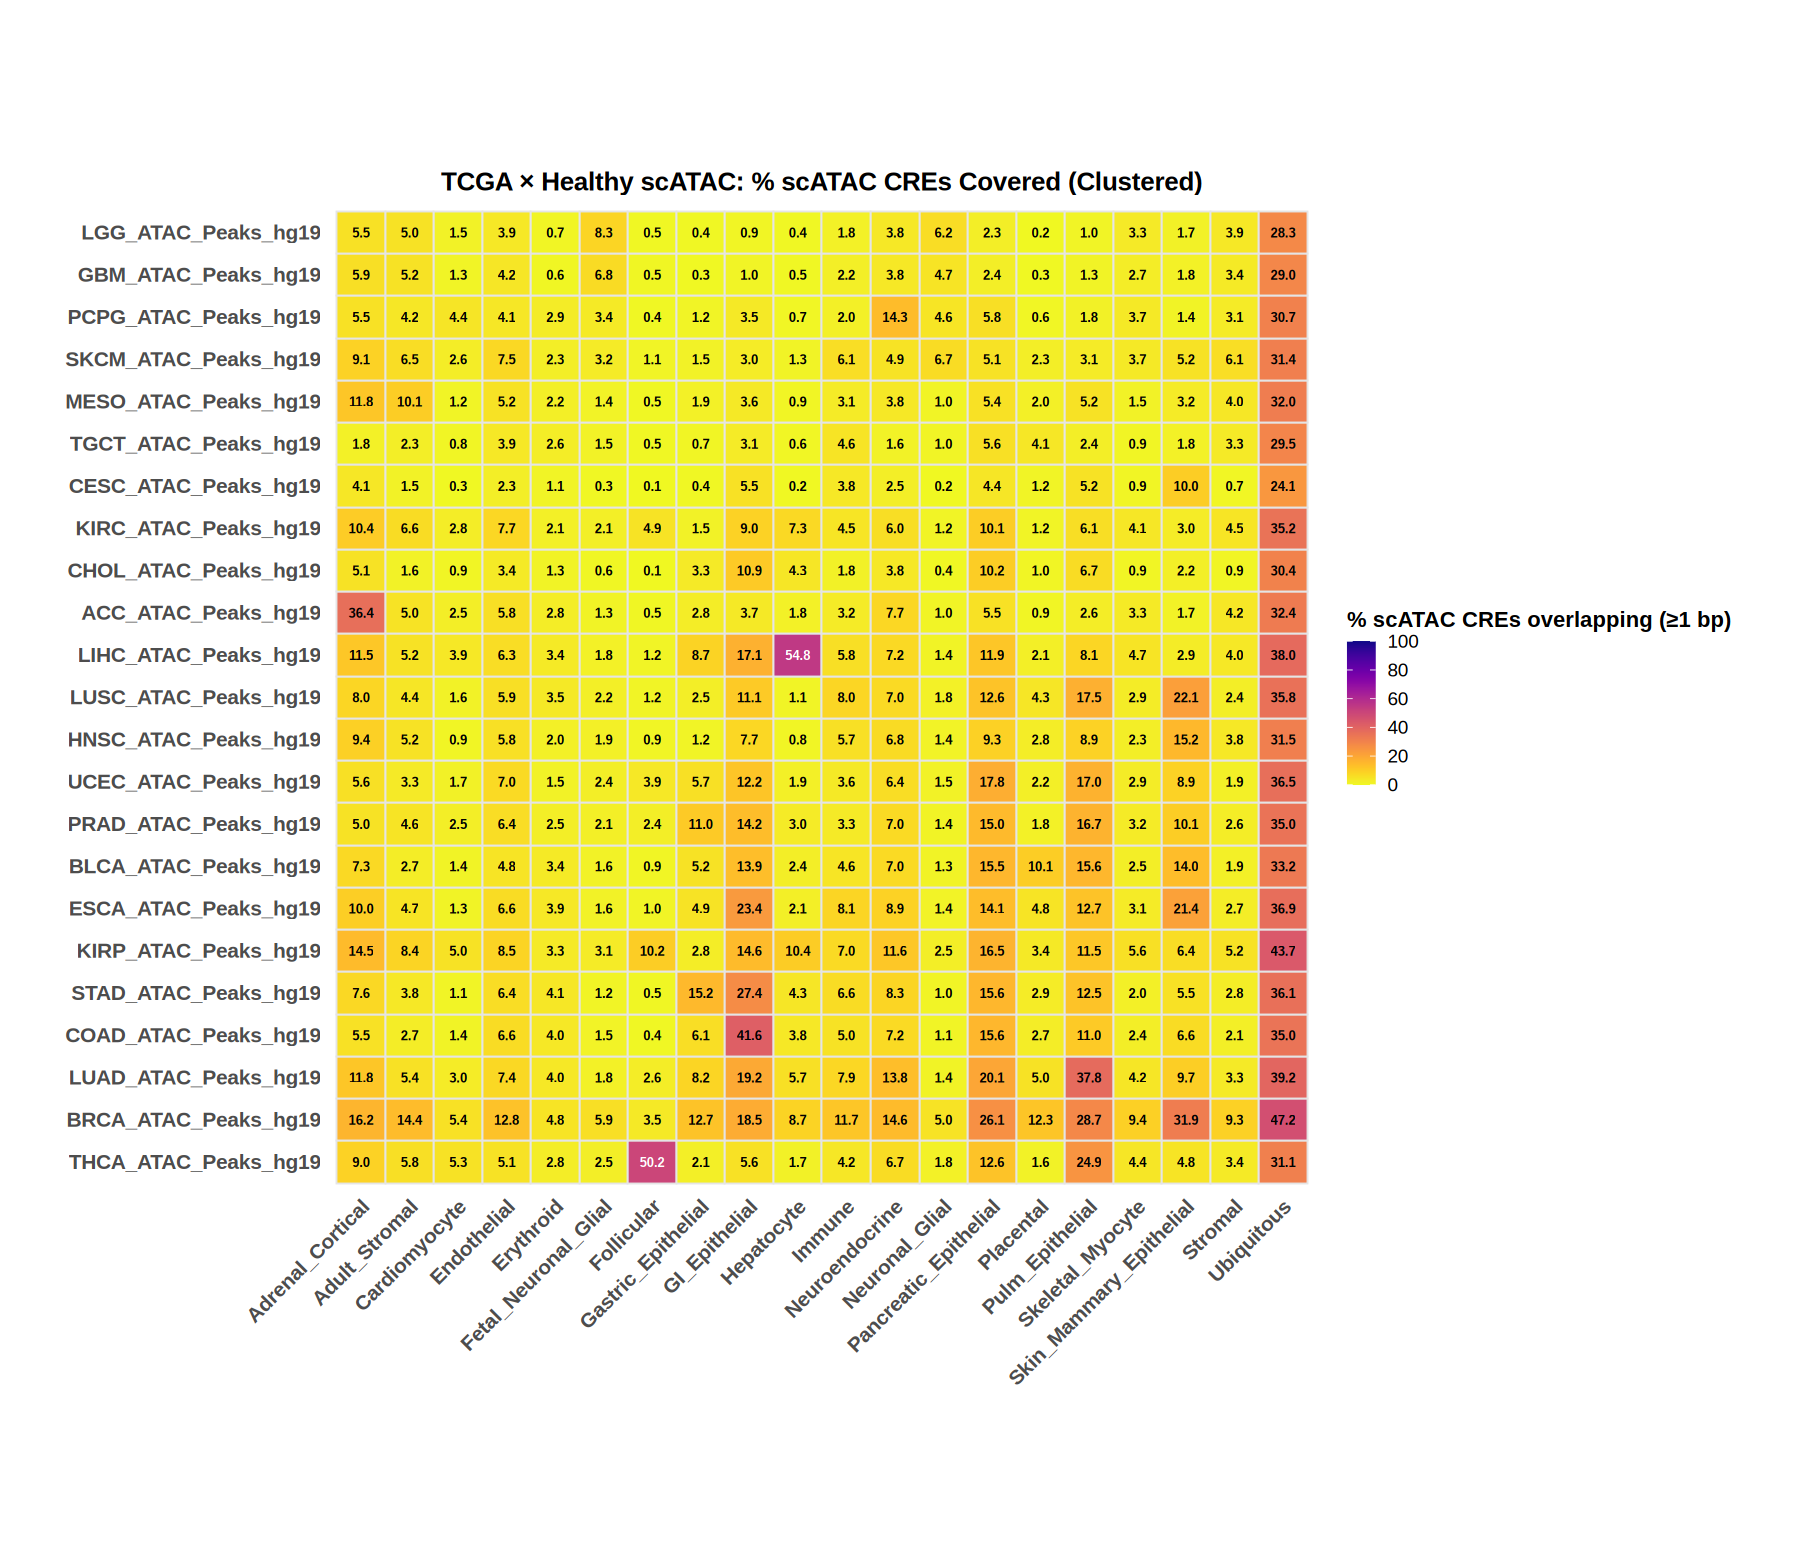

In [17]:
# ===================================================================
# Clustered heatmap: TCGA × Healthy scATAC (% scATAC covered)
# Ensures full TCGA abbreviations (e.g. LUAD) are shown
# ===================================================================

library(data.table)
library(ggplot2)
library(viridis)

# ------------------------------------------------
# Load your matrix
# ------------------------------------------------
mat_file <- "../ref/CRE_sites_Selective/TCGA_sites_Selective3/matrix_pct_scATAC_covered_by_TCGA_wide.csv"
df <- fread(mat_file)

# Explicitly set row names
mat <- as.matrix(df[, -1, with = FALSE])
rownames(mat) <- df$Cancer  # make sure Cancer column = LUAD, BRCA, etc.

# ------------------------------------------------
# Cluster ordering
# ------------------------------------------------
hc_rows <- hclust(dist(mat))
hc_cols <- hclust(dist(t(mat)))
mat_ord <- mat[hc_rows$order, hc_cols$order, drop = FALSE]

# ------------------------------------------------
# Melt for ggplot
# ------------------------------------------------
melt_dt <- as.data.table(as.table(mat_ord))
setnames(melt_dt, c("Cancer","CellType","value"))

# Ensure Cancer names (row labels) stay intact (e.g. LUAD)
melt_dt$Cancer <- factor(melt_dt$Cancer, levels = rownames(mat_ord))

# ------------------------------------------------
# Plot formatting
# ------------------------------------------------
n_rows <- nrow(mat_ord)
n_cols <- ncol(mat_ord)
tile_text_size <- 6 * (10 / max(n_rows, n_cols))
melt_dt$text_color <- ifelse(melt_dt$value > 50, "white", "black")

# ------------------------------------------------
# Plot
# ------------------------------------------------
gf <- ggplot(melt_dt, aes(x = CellType, y = Cancer, fill = value)) +
  geom_tile(color = "grey90", linewidth = 0.4) +
  geom_text(aes(label = sprintf("%.1f", value), color = text_color),
            size = tile_text_size, fontface = "bold") +
  scale_color_identity() +
  scale_fill_viridis(
    name = "% scATAC CREs overlapping (≥1 bp)",
    option = "C", direction = -1,
    limits = c(0, 100), breaks = seq(0, 100, by = 20)
  ) +
  coord_fixed() +
  theme_minimal(base_size = 14) +
  theme(
    aspect.ratio = 1,
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1,
                               size = 12, face = "bold"),
    axis.text.y = element_text(size = 12, face = "bold"),
    axis.title  = element_blank(),
    panel.grid  = element_blank(),
    legend.position = "right",
    legend.title = element_text(face = "bold", size = 13),
    legend.text  = element_text(size = 11),
    plot.title   = element_text(face = "bold", hjust = 0.5, size = 15),
    plot.margin  = margin(20, 40, 20, 40)
  ) +
  ggtitle("TCGA × Healthy scATAC: % scATAC CREs Covered (Clustered)")

# ------------------------------------------------
# Display inline in Jupyter
# ------------------------------------------------
options(repr.plot.width = 15, repr.plot.height = 13)
print(gf)


In [18]:
ggsave(
  filename = "../ref/CRE_sites_Selective/TCGA_sites_Selective3/heatmap_pct_scATAC_covered_by_TCGA_FINAL.png",
  plot = gf,
  width = 14,     # inches
  height = 12,    # inches
  dpi = 300       # publication-quality resolution
)


scATAC dir: ../ref/CRE_sites_Selective/scATAC_sites_Selective3
TCGA dir: ../ref/CRE_sites_Selective/TCGA_sites_Selective3
Output: ../ref/CRE_sites_Selective/TCGA_vs_scATAC_overlap

Found 20 scATAC and 24 TCGA files
Computing pairwise overlaps …

✅ Heatmap saved to: ../ref/CRE_sites_Selective/TCGA_vs_scATAC_overlap


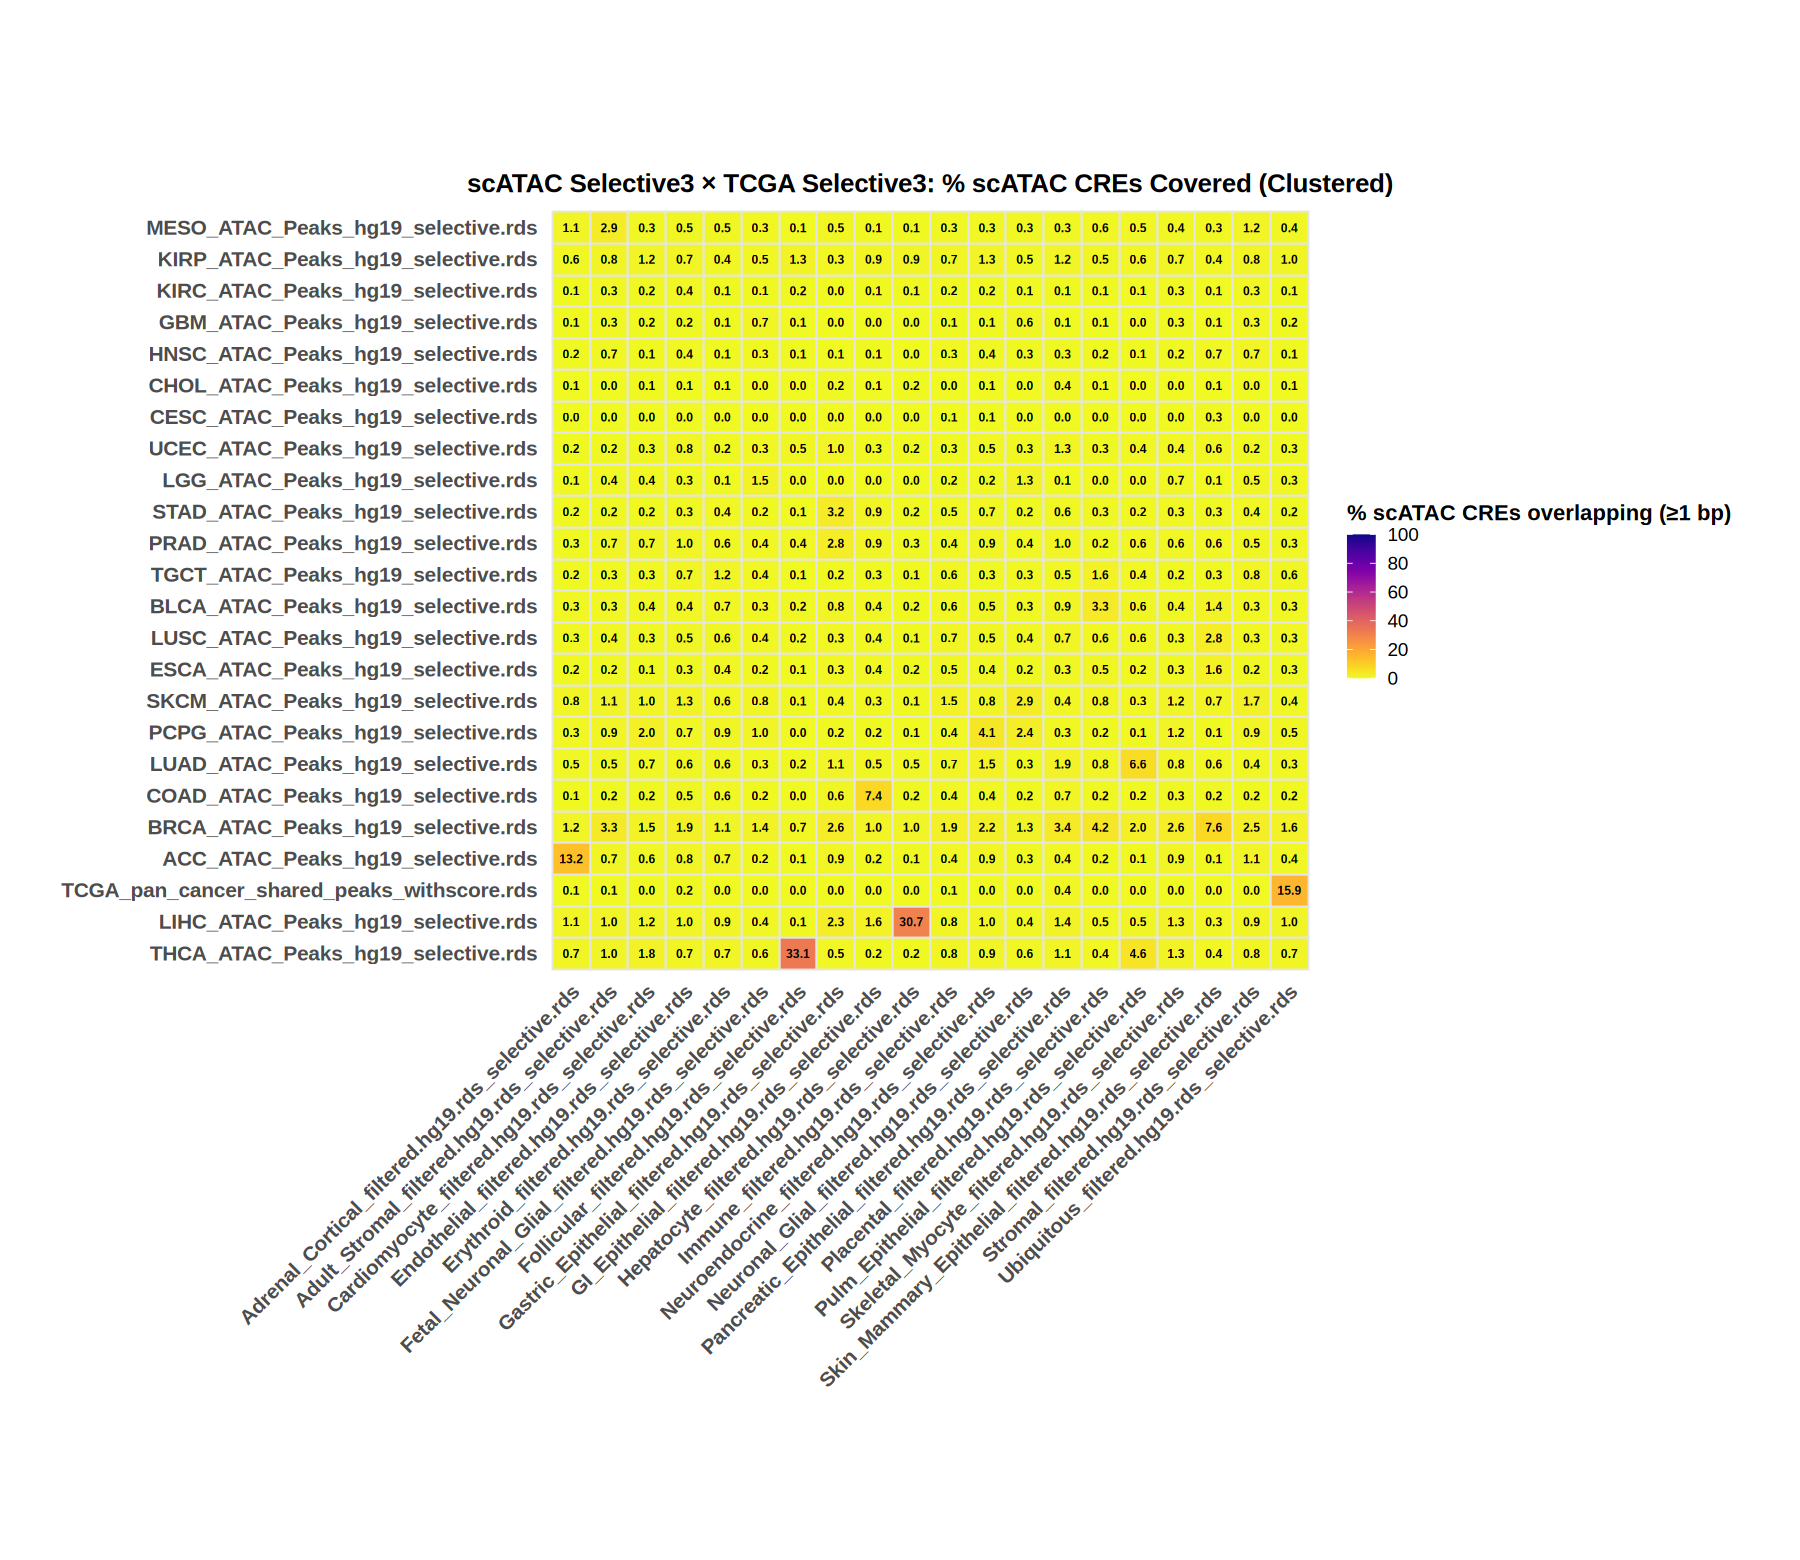

In [40]:
# ===================================================================
# Cross-dataset overlap: scATAC (healthy, Selective3) × TCGA (cancer, Selective3)
# ===================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(ggplot2)
  library(viridis)
  library(fs)
})

# ------------------------------------------------
# Paths
# ------------------------------------------------
scatac_dir <- "../ref/CRE_sites_Selective/scATAC_sites_Selective3"
tcga_dir   <- "../ref/CRE_sites_Selective/TCGA_sites_Selective3"
out_dir    <- "../ref/CRE_sites_Selective/TCGA_vs_scATAC_overlap"

cat(sprintf("scATAC dir: %s\nTCGA dir: %s\nOutput: %s\n\n", scatac_dir, tcga_dir, out_dir))

# ------------------------------------------------
# Helper functions
# ------------------------------------------------
get_name <- function(path) gsub("_filtered(\\.hg19)?\\.rds$", "", basename(path))
reduce_if_needed <- function(gr) {
  if (!inherits(gr, "GRanges")) gr <- unlist(GRangesList(gr))
  reduce(gr, ignore.strand = TRUE)
}
pct_A_covers_B <- function(A, B) {
  if (length(A) == 0 || length(B) == 0) return(0)
  hits <- findOverlaps(B, A, ignore.strand = TRUE)
  100 * length(unique(queryHits(hits))) / length(B)
}

# ------------------------------------------------
# Load files
# ------------------------------------------------
scatac_files <- list.files(scatac_dir, pattern="\\.rds$", full.names = TRUE)
tcga_files   <- list.files(tcga_dir,   pattern="\\.rds$", full.names = TRUE)

scatac_names <- vapply(scatac_files, get_name, character(1))
tcga_names   <- vapply(tcga_files,   get_name, character(1))

cat(sprintf("Found %d scATAC and %d TCGA files\n", length(scatac_files), length(tcga_files)))

scatac_list <- lapply(scatac_files, function(f) reduce_if_needed(readRDS(f)))
names(scatac_list) <- scatac_names
tcga_list   <- lapply(tcga_files,   function(f) reduce_if_needed(readRDS(f)))
names(tcga_list)   <- tcga_names

# ------------------------------------------------
# Compute overlaps
# ------------------------------------------------
M <- matrix(0, nrow = length(tcga_list), ncol = length(scatac_list),
            dimnames = list(tcga_names, scatac_names))

cat("Computing pairwise overlaps …\n")
for (i in seq_along(tcga_list)) {
  A <- tcga_list[[i]]
  for (j in seq_along(scatac_list)) {
    B <- scatac_list[[j]]
    M[i, j] <- pct_A_covers_B(A, B)
  }
}

# ------------------------------------------------
# Clustered heatmap
# ------------------------------------------------
hc_rows <- hclust(dist(M))
hc_cols <- hclust(dist(t(M)))
M_ord <- M[hc_rows$order, hc_cols$order, drop = FALSE]

melt_dt <- as.data.table(as.table(M_ord))
setnames(melt_dt, c("Cancer","CellType","value"))
melt_dt$Cancer <- factor(melt_dt$Cancer, levels = rownames(M_ord))
melt_dt$text_color <- ifelse(melt_dt$value > 50, "white", "black")
tile_text_size <- 6 * (10 / max(nrow(M_ord), ncol(M_ord)))

gf <- ggplot(melt_dt, aes(x = CellType, y = Cancer, fill = value)) +
  geom_tile(color = "grey90", linewidth = 0.4) +
  geom_text(aes(label = sprintf("%.1f", value), color = text_color),
            size = tile_text_size, fontface = "bold") +
  scale_color_identity() +
  scale_fill_viridis(name="% scATAC CREs overlapping (≥1 bp)",
                     option="C", direction=-1, limits=c(0,100),
                     breaks=seq(0,100,by=20)) +
  coord_fixed() +
  theme_minimal(base_size=14) +
  theme(
    aspect.ratio = 1,
    axis.text.x  = element_text(angle=45,hjust=1,vjust=1,face="bold",size=12),
    axis.text.y  = element_text(face="bold",size=12),
    axis.title   = element_blank(),
    panel.grid   = element_blank(),
    legend.position = "right",
    legend.title = element_text(face="bold",size=13),
    legend.text  = element_text(size=11),
    plot.title   = element_text(face="bold",hjust=0.5,size=15),
    plot.margin  = margin(20,40,20,40)
  ) +
  ggtitle("scATAC Selective3 × TCGA Selective3: % scATAC CREs Covered (Clustered)")

options(repr.plot.width=15, repr.plot.height=13)
print(gf)

ggsave(file.path(out_dir, "heatmap_scATAC_TCGA_Selective3.png"),
       plot=gf, width=14, height=12, dpi=300)
cat(sprintf("\n✅ Heatmap saved to: %s\n", out_dir))


scATAC dir: ../ref/CRE_sites_Selective/scATAC_sites_Selective3
TCGA Organ dir: ../ref/CRE_sites_Selective/TCGA_Organ_Selective_v3
Output: ../ref/CRE_sites_Selective/TCGA_Organ_vs_scATAC_overlap

Found 20 scATAC and 14 TCGA Organ files
Computing pairwise overlaps …

✅ Heatmap saved to: ../ref/CRE_sites_Selective/TCGA_Organ_vs_scATAC_overlap


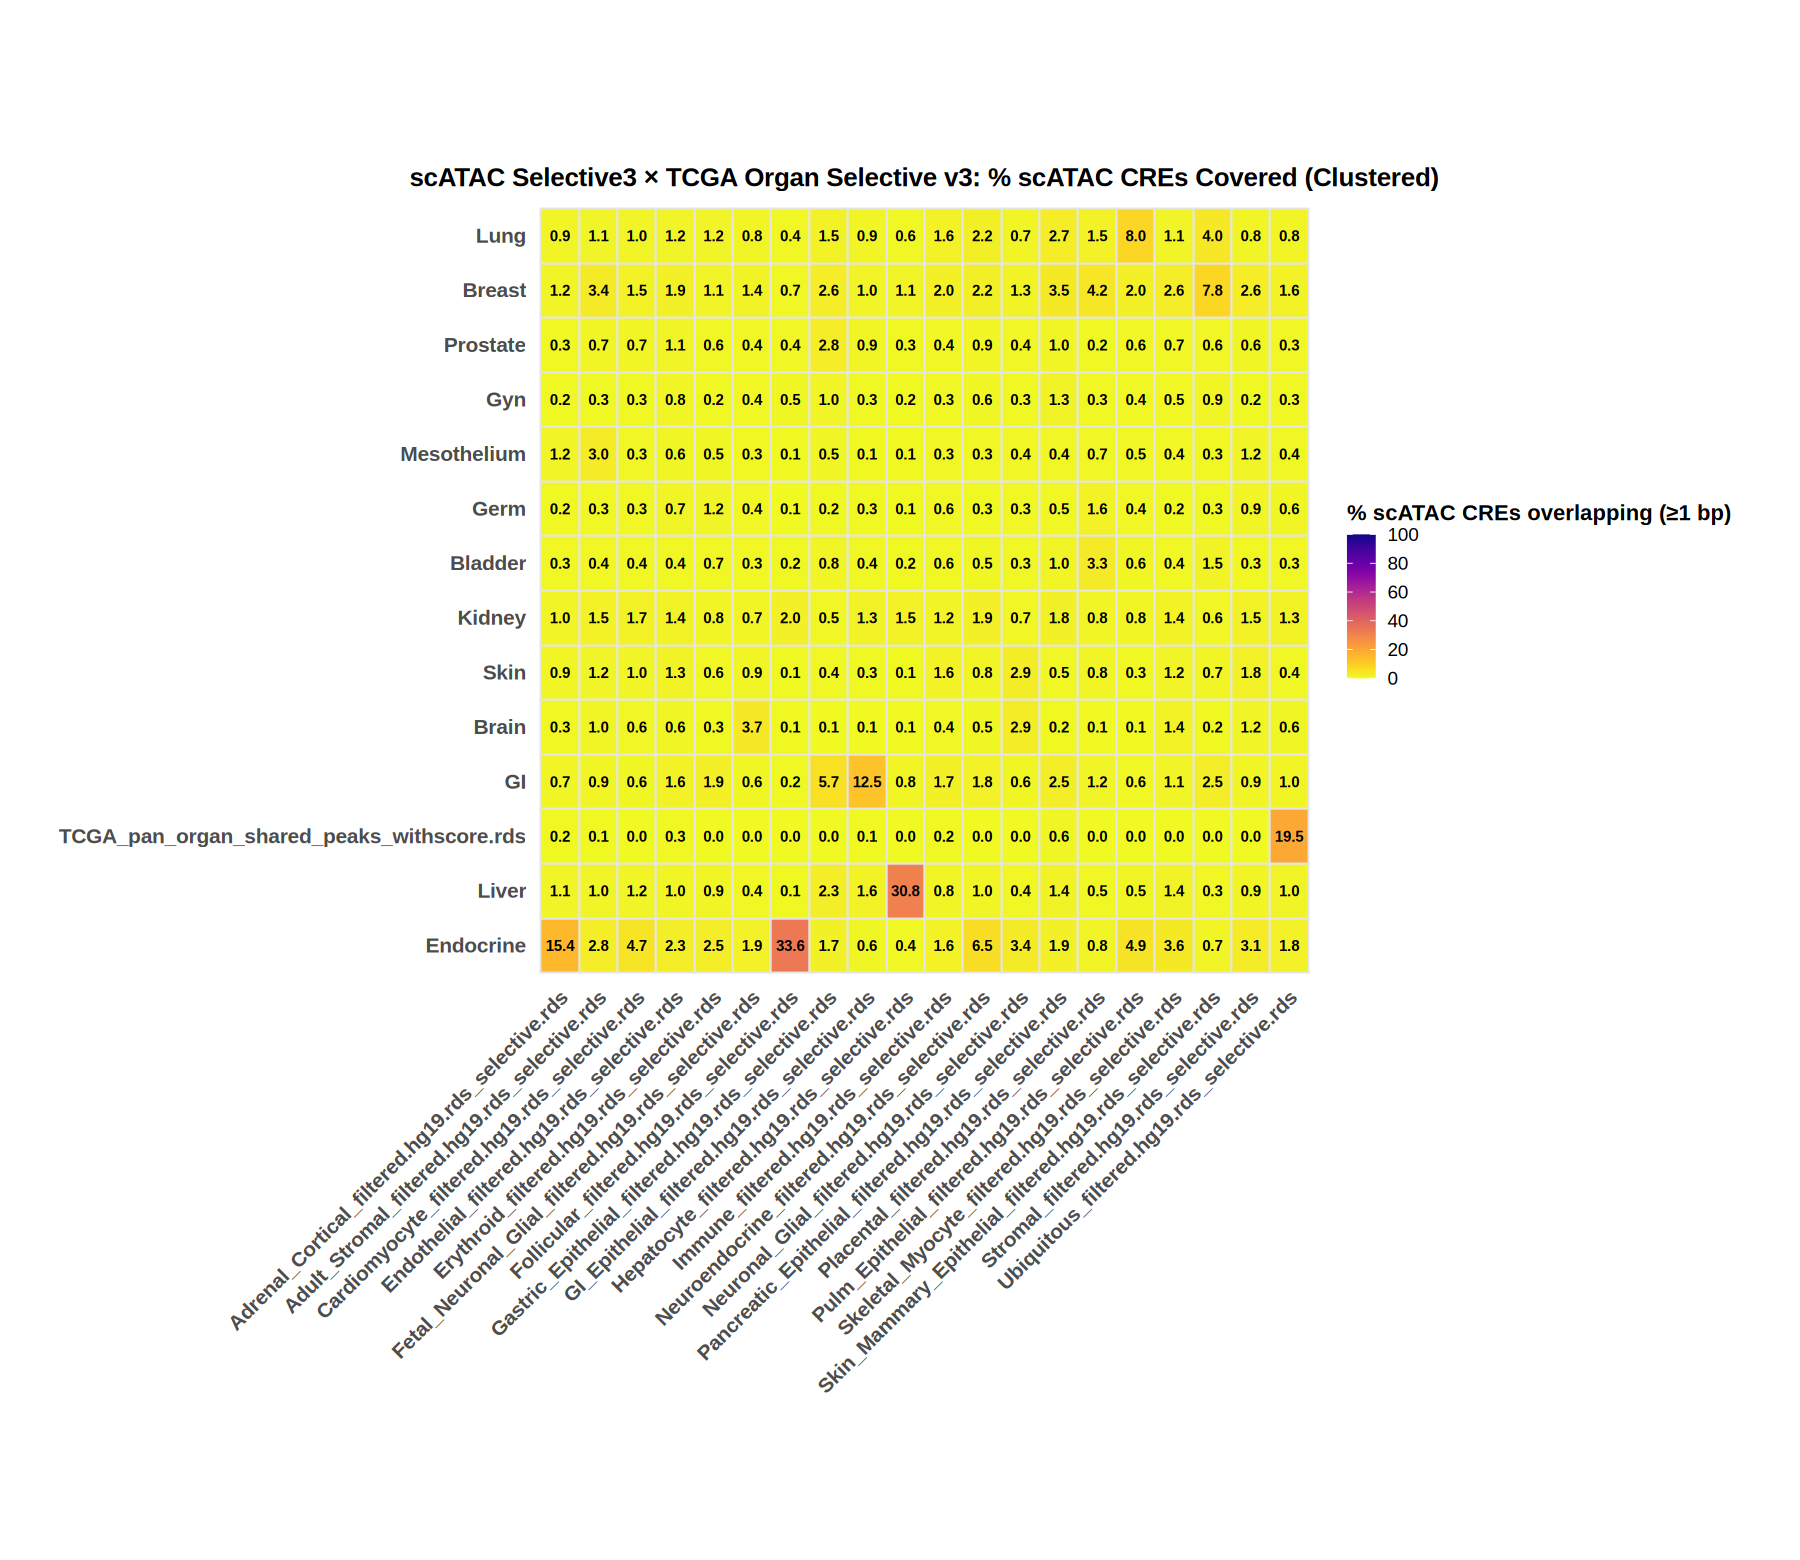

In [41]:
#!/usr/bin/env Rscript
# ===================================================================
# Cross-dataset overlap: scATAC (healthy, Selective3) × TCGA (Organ-level, Selective v3)
# ===================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(ggplot2)
  library(viridis)
  library(fs)
})

# ------------------------------------------------
# Paths
# ------------------------------------------------
scatac_dir <- "../ref/CRE_sites_Selective/scATAC_sites_Selective3"
tcga_dir   <- "../ref/CRE_sites_Selective/TCGA_Organ_Selective_v3"
out_dir    <- "../ref/CRE_sites_Selective/TCGA_Organ_vs_scATAC_overlap"
dir_create(out_dir)

cat(sprintf("scATAC dir: %s\nTCGA Organ dir: %s\nOutput: %s\n\n", scatac_dir, tcga_dir, out_dir))

# ------------------------------------------------
# Helper functions
# ------------------------------------------------
get_name <- function(path) gsub("_filtered(\\.hg19)?\\.rds$", "", basename(path))
reduce_if_needed <- function(gr) {
  if (!inherits(gr, "GRanges")) gr <- unlist(GRangesList(gr))
  reduce(gr, ignore.strand = TRUE)
}
pct_A_covers_B <- function(A, B) {
  if (length(A) == 0 || length(B) == 0) return(0)
  hits <- findOverlaps(B, A, ignore.strand = TRUE)
  100 * length(unique(queryHits(hits))) / length(B)
}

# ------------------------------------------------
# Load files
# ------------------------------------------------
scatac_files <- list.files(scatac_dir, pattern="\\.rds$", full.names = TRUE)
tcga_files   <- list.files(tcga_dir,   pattern="\\.rds$", full.names = TRUE)

scatac_names <- gsub("_filtered(\\.hg19)?\\.rds$", "", basename(scatac_files))
tcga_names   <- gsub("_organ_selective\\.rds$", "", basename(tcga_files))

cat(sprintf("Found %d scATAC and %d TCGA Organ files\n", length(scatac_files), length(tcga_files)))

scatac_list <- lapply(scatac_files, function(f) reduce_if_needed(readRDS(f)))
names(scatac_list) <- scatac_names

tcga_list <- lapply(tcga_files, function(f) reduce_if_needed(readRDS(f)))
names(tcga_list) <- tcga_names

# ------------------------------------------------
# Compute overlaps
# ------------------------------------------------
M <- matrix(0, nrow = length(tcga_list), ncol = length(scatac_list),
            dimnames = list(tcga_names, scatac_names))

cat("Computing pairwise overlaps …\n")
for (i in seq_along(tcga_list)) {
  A <- tcga_list[[i]]
  for (j in seq_along(scatac_list)) {
    B <- scatac_list[[j]]
    M[i, j] <- pct_A_covers_B(A, B)
  }
}

# ------------------------------------------------
# Clustered heatmap
# ------------------------------------------------
hc_rows <- hclust(dist(M))
hc_cols <- hclust(dist(t(M)))
M_ord <- M[hc_rows$order, hc_cols$order, drop = FALSE]

melt_dt <- as.data.table(as.table(M_ord))
setnames(melt_dt, c("Organ","CellType","value"))
melt_dt$Organ <- factor(melt_dt$Organ, levels = rownames(M_ord))
melt_dt$text_color <- ifelse(melt_dt$value > 50, "white", "black")
tile_text_size <- 6 * (10 / max(nrow(M_ord), ncol(M_ord)))

gf <- ggplot(melt_dt, aes(x = CellType, y = Organ, fill = value)) +
  geom_tile(color = "grey90", linewidth = 0.4) +
  geom_text(aes(label = sprintf("%.1f", value), color = text_color),
            size = tile_text_size, fontface = "bold") +
  scale_color_identity() +
  scale_fill_viridis(name="% scATAC CREs overlapping (≥1 bp)",
                     option="C", direction=-1, limits=c(0,100),
                     breaks=seq(0,100,by=20)) +
  coord_fixed() +
  theme_minimal(base_size=14) +
  theme(
    aspect.ratio = 1,
    axis.text.x  = element_text(angle=45,hjust=1,vjust=1,face="bold",size=12),
    axis.text.y  = element_text(face="bold",size=12),
    axis.title   = element_blank(),
    panel.grid   = element_blank(),
    legend.position = "right",
    legend.title = element_text(face="bold",size=13),
    legend.text  = element_text(size=11),
    plot.title   = element_text(face="bold",hjust=0.5,size=15),
    plot.margin  = margin(20,40,20,40)
  ) +
  ggtitle("scATAC Selective3 × TCGA Organ Selective v3: % scATAC CREs Covered (Clustered)")

options(repr.plot.width=15, repr.plot.height=13)
print(gf)

ggsave(file.path(out_dir, "heatmap_scATAC_TCGA_Organ_Selective_v3.png"),
       plot=gf, width=14, height=12, dpi=300)
cat(sprintf("\n✅ Heatmap saved to: %s\n", out_dir))


### Final QC of TCGA

In [36]:
#!/usr/bin/env Rscript
# ===================================================================
# Simple Metadata QC – TCGA Organ & Selective CRE Files
# ===================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(fs)
})

# ------------------------------------------------
# Directories
# ------------------------------------------------
dirs <- list(
  Selective = "../ref/CRE_sites_Selective/TCGA_sites_Selective3",
  Organ     = "../ref/CRE_sites_Selective/TCGA_Organ_Selective_v3"
)

# Output summary file
out_csv <- "../ref/CRE_sites_Selective/TCGA_CRE_Metadata_QC.csv"

# ------------------------------------------------
# Helper function to extract metadata info
# ------------------------------------------------
get_metadata_info <- function(file, dataset) {
  gr <- tryCatch(readRDS(file), error = function(e) NULL)
  if (is.null(gr) || !inherits(gr, "GRanges")) {
    return(data.frame(
      Dataset = dataset,
      File = basename(file),
      Is_GRanges = FALSE,
      N_Peaks = NA,
      Metadata_Columns = NA,
      Has_Score = FALSE,
      stringsAsFactors = FALSE
    ))
  }
  
  meta_cols <- names(mcols(gr))
  has_score <- "score" %in% meta_cols
  
  data.frame(
    Dataset = dataset,
    File = basename(file),
    Is_GRanges = TRUE,
    N_Peaks = length(gr),
    Metadata_Columns = paste(meta_cols, collapse = ", "),
    Has_Score = has_score,
    stringsAsFactors = FALSE
  )
}

# ------------------------------------------------
# Run QC
# ------------------------------------------------
qc_list <- list()
for (label in names(dirs)) {
  dir_path <- dirs[[label]]
  if (!dir_exists(dir_path)) {
    warning(sprintf("Directory not found: %s", dir_path))
    next
  }
  
  files <- dir_ls(dir_path, regexp = "\\.rds$")
  if (length(files) == 0) next
  
  qc_list[[label]] <- do.call(rbind, lapply(files, get_metadata_info, dataset = label))
}

# Combine and save
qc_df <- rbindlist(qc_list, fill = TRUE)
qc_df <- qc_df[order(Dataset, File)]

fwrite(qc_df, out_csv)

# Print concise summary
cat("\n================ TCGA CRE Metadata QC ================\n")
print(qc_df[, .(Dataset, File, N_Peaks, Has_Score, Metadata_Columns)])
cat("\n✅ Metadata QC summary saved to:\n", out_csv, "\n")



================ TCGA CRE Metadata QC ================
      Dataset                                       File N_Peaks Has_Score
       <char>                                     <char>   <int>    <lgcl>
 1:     Organ                Bladder_organ_selective.rds    7601      TRUE
 2:     Organ                  Brain_organ_selective.rds   11470      TRUE
 3:     Organ                 Breast_organ_selective.rds   27157      TRUE
 4:     Organ              Endocrine_organ_selective.rds   28181      TRUE
 5:     Organ                     GI_organ_selective.rds   21844      TRUE
 6:     Organ                   Germ_organ_selective.rds    7994      TRUE
 7:     Organ                    Gyn_organ_selective.rds    4956      TRUE
 8:     Organ                 Kidney_organ_selective.rds   12527      TRUE
 9:     Organ                  Liver_organ_selective.rds   12763      TRUE
10:     Organ                   Lung_organ_selective.rds   16505      TRUE
11:     Organ            Mesothelium_organ_s

In [44]:
library(GenomicRanges)

# ---- Replace with your file path ----
f <- "../ref/CRE_sites_Selective/TCGA_sites_Selective3/TCGA_pan_cancer_shared_peaks_withscore.rds"

# ---- Load and inspect ----
gr <- readRDS(f)
cat("Columns:\n"); print(names(mcols(gr)))

# ---- Check for missing values ----
na_counts <- colSums(is.na(as.data.frame(mcols(gr))))
cat("\nMissing values per column:\n")
print(na_counts)


Columns:
[1] "score"

Missing values per column:
score 
    0 


In [45]:
gr

GRanges object with 7770 ranges and 1 metadata column:
         seqnames              ranges strand |     score
            <Rle>           <IRanges>  <Rle> | <numeric>
     [1]     chr1       948562-949126      * |   26.7494
     [2]     chr1     1014683-1015931      * |   23.9153
     [3]     chr1     1310501-1311071      * |   62.8401
     [4]     chr1     1655596-1656142      * |   46.8807
     [5]     chr1     1677623-1678147      * |   25.6138
     ...      ...                 ...    ... .       ...
  [7766]     chrX 153626970-153627509      * |   15.9121
  [7767]     chrX 153656649-153657221      * |   39.7094
  [7768]     chrX 153762930-153763482      * |   26.6798
  [7769]     chrX 154033502-154034077      * |   25.1459
  [7770]     chrX 154444373-154444900      * |   36.5739
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

In [46]:
library(GenomicRanges)

# ---- Replace with your file path ----
f <- "../ref/CRE_sites_Selective/TCGA_sites_Selective3/LUAD_ATAC_Peaks_hg19_selective.rds"

# ---- Load and inspect ----
gr <- readRDS(f)
cat("Columns:\n"); print(names(mcols(gr)))

# ---- Check for missing values ----
na_counts <- colSums(is.na(as.data.frame(mcols(gr))))
cat("\nMissing values per column:\n")
print(na_counts)

Columns:
[1] "name"       "score"      "annotation" "percentGC"  "percentAT" 
[6] "CRE_source"

Missing values per column:
      name      score annotation  percentGC  percentAT CRE_source 
         0          0          0          0          0          0 


In [47]:
gr

GRanges object with 8415 ranges and 6 metadata columns:
         seqnames              ranges strand |        name     score
            <Rle>           <IRanges>  <Rle> | <character> <numeric>
     [1]     chr1     4846127-4846628      * |    LUAD_480   4.06482
     [2]     chr1   32662616-32663117      * |   LUAD_2864   4.53618
     [3]     chr1 145697889-145698390      * |   LUAD_6559   5.73921
     [4]     chr1 147101803-147102304      * |   LUAD_6711   4.10633
     [5]     chr1 151314256-151314757      * |   LUAD_7035   5.26919
     ...      ...                 ...    ... .         ...       ...
  [8411]     chrX   10545036-10545537      * | LUAD_137000   3.88341
  [8412]     chrX   49013595-49014096      * | LUAD_137680   3.92420
  [8413]     chrX   85159023-85159524      * | LUAD_138145   6.80460
  [8414]     chrX 153041600-153042101      * | LUAD_139036   5.17980
  [8415]     chrX 153579968-153580469      * | LUAD_139069   7.72795
          annotation percentGC percentAT       

In [48]:
library(GenomicRanges)

# ---- Replace with your file path ----
f <- "../ref/CRE_sites_Selective/TCGA_Organ_Selective_v3/Bladder_organ_selective.rds"

# ---- Load and inspect ----
gr <- readRDS(f)
cat("Columns:\n"); print(names(mcols(gr)))

# ---- Check for missing values ----
na_counts <- colSums(is.na(as.data.frame(mcols(gr))))
cat("\nMissing values per column:\n")
print(na_counts)

Columns:
[1] "score"

Missing values per column:
score 
    0 


In [49]:
gr

GRanges object with 7601 ranges and 1 metadata column:
         seqnames            ranges strand |     score
            <Rle>         <IRanges>  <Rle> | <numeric>
     [1]     chr1     780968-781469      * |  10.26020
     [2]     chr1     915384-915885      * |   5.19133
     [3]     chr1     931137-931638      * |  10.75861
     [4]     chr1     994126-994627      * |   4.67564
     [5]     chr1   1449687-1450188      * |   6.18398
     ...      ...               ...    ... .       ...
  [7597]     chrY 23737243-23737744      * |  12.98033
  [7598]     chrY 23747260-23747761      * |   5.32936
  [7599]     chrY 23750917-23751418      * |   7.94640
  [7600]     chrY 24001733-24002234      * |  12.67639
  [7601]     chrY 24002300-24002801      * |   7.10947
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths